<a href="https://colab.research.google.com/github/LorenzoBioinfo/EcoliGTP/blob/main/dna_lm_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNA Language Model: Teaching a GPT to Read the Genome

**Cosa impara un language model addestrato sul DNA, senza che nessuno gli abbia spiegato cosa siano  codoni, ribosomi o aminoacidi?**

L'idea di questo notebook è di costruire da zero un transformer decoder-only e addestrarlo sull'intero genoma di *Escherichia coli* K-12 (~4.6 Mb, ~4.300 geni annotati).
Dopo l'addestramento, eseguiamo una serie di "esperimenti" per capire cosa ha imparato del funzionamento del DNA.


**Analogia biologica:**

| Linguaggio naturale | DNA |
|---|---|
| Caratteri (a, b, c, …) | Nucleotidi (A, T, C, G) |
| Parole | Codoni (triplette, es. ATG) |
| Frasi | Geni |
| Libro | Genoma |

Tokenizziamo **nucleotidi singoli (k=1)** — non codoni — vocabolario: **8 token**.
Avremmo potuto usare come k=3 e passare direttamente i codoni come token. Vogliamo però *sfidare* il modello e
deve *riscoprire da solo* la struttura a codoni del DNA.

---

**Struttura del notebook:**
1. **Dati** — download del genoma di *E. coli*, estrazione delle regioni annotate, costruzione del tokenizer con k=1
2. **Modello & Training** — architettura transformer decoder-only, training di due varianti (Standard PE vs Bio PE)
3. **Esperimenti** — cosa ha imparato il modello su geni, codoni e regioni codificanti?


In [49]:
# Installiamo le librerie necessarie e eseguiamo i corrispettivi import
!pip install biopython requests matplotlib torch umap-learn seaborn scikit-learn -q

import json, math, pickle, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from pathlib import Path
from dataclasses import dataclass
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from torch.utils.data import Dataset, DataLoader
from Bio import Entrez, SeqIO
from Bio.Seq import Seq as BioSeq
from Bio.SeqRecord import SeqRecord
from scipy import stats
from scipy.spatial.distance import cosine
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Uncomment to mount Google Drive on Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# import os; os.chdir('/content/drive/MyDrive/dna_lm')

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)
Path('checkpoints').mkdir(exist_ok=True)


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


---
## Sezione 1 — Dati: Il Genoma di *E. coli* K-12


## 1. Download del genoma di E. coli K-12 da NCBI

Usiamo l'accession **U00096** (E. coli K-12 MG1655), il ceppo di riferimento,
completamente annotato, genoma circolare di ~4.6 Mb.
Scarichiamo i dati direttamente da NCBI.

In [50]:
def download_ecoli_genome(email: str = 'your@email.com') -> SeqRecord:
    """Scarica il genoma completo di E. coli K-12 MG1655 da NCBI."""
    genome_path = DATA_DIR / 'ecoli_k12.gb'

    if genome_path.exists():
        print('Genoma già scaricato, carico dal file...')
        return SeqIO.read(str(genome_path), 'genbank')

    print('Scaricamento da NCBI (può richiedere qualche minuto)...')
    Entrez.email = email

    handle = Entrez.efetch(
        db='nucleotide',
        id='U00096.3',
        rettype='gb',
        retmode='text'
    )
    record = SeqIO.read(handle, 'genbank')
    handle.close()

    SeqIO.write(record, str(genome_path), 'genbank')
    print(f'Salvato in {genome_path}')
    return record


# Inserisci la tua email NCBI
NCBI_EMAIL = 'your.email@example.com'
record = download_ecoli_genome(email=NCBI_EMAIL)

genome_seq = str(record.seq).upper()
print(f'\nOrganismo: {record.description}')
print(f'Lunghezza genoma: {len(genome_seq)} bp')
print(f'Composizione nucleotidica:')
for nuc in 'ATCG':
    pct = genome_seq.count(nuc) / len(genome_seq) * 100
    print(f'  {nuc}: {pct:.1f}%')

Genoma già scaricato, carico dal file...

Organismo: Escherichia coli str. K-12 substr. MG1655, complete genome
Lunghezza genoma: 4641652 bp
Composizione nucleotidica:
  A: 24.6%
  T: 24.6%
  C: 25.4%
  G: 25.4%


## 2. Estrazione delle annotazioni: CDS vs non-codificanti

Il genoma di *E. coli* è annotato: sappiamo esattamente dove inizia e finisce ogni gene.

**Regioni codificanti (CDS, Coding Sequence):** tratti di DNA trascritti in RNA
e poi tradotti in proteine. Iniziano quasi sempre con il codone di start **ATG** (Metionina)
e terminano con un codone di stop (TAA, TAG o TGA).

**Regioni non-codificanti:** gli spazi tra i geni — includono promotori, sequenze regolatrici
e 5'UTR (regioni non tradotte a monte dei geni). Statisticamente meno regolari rispetto alle CDS.

Estraiamo queste regioni per due esperimenti:
- **Esperimento 1 (Shine-Dalgarno):** per ogni CDS, salviamo anche ~50 bp upstream dell'ATG.
  In questa zona si trova il sito di legame del ribosoma (**sequenza di Shine-Dalgarno**),
  che il modello potrebbe aver imparato a riconoscere statisticamente durante il training.
- **Esperimento 3 (perplexity):** confrontiamo quanto il modello "si sorprende"
  su CDS vs regioni non-codificanti.

In [51]:
def extract_regions(record: SeqRecord, genome_seq: str) -> dict:
    """
    Estrae CDS e regioni non-codificanti dal genoma annotato.

    Per ogni CDS salva anche una versione 'estesa' che include ~50 bp
    di sequenza upstream (5'UTR), dove si trova il sito Shine-Dalgarno.
    Questa è usata nell'Esperimento 1 del notebook 03.
    """
    UPSTREAM = 50  # bp a monte dell'ATG da includere nelle sequenze estese

    cds_regions   = []
    cds_sequences = []
    extended_cds  = []  # CDS + contesto upstream (include il sito Shine-Dalgarno)

    for feature in record.features:
        if feature.type == 'CDS':
            start  = int(feature.location.start)
            end    = int(feature.location.end)
            strand = feature.location.strand
            seq    = str(feature.extract(record.seq)).upper()

            # Teniamo solo CDS lunghe almeno 60 bp e senza N
            if len(seq) >= 60 and 'N' not in seq:
                cds_regions.append((start, end, strand))
                cds_sequences.append(seq)

                # Sequenza estesa con contesto upstream
                # Per strand +: upstream è a coordinate inferiori (prima del gene)
                # Per strand -: upstream è a coordinate superiori (dopo il gene in forward)
                #   ma dopo il reverse complement corrisponde all'inizio in 5'->3'
                if strand == 1:
                    up_start = max(0, start - UPSTREAM)
                    ext_seq  = genome_seq[up_start:end]
                else:
                    dn_end  = min(len(genome_seq), end + UPSTREAM)
                    # revcomp di [start:end+UPSTREAM] = upstream + CDS in 5'->3'
                    ext_seq = str(BioSeq(genome_seq[start:dn_end]).reverse_complement()).upper()

                if 'N' not in ext_seq:
                    extended_cds.append(ext_seq)
                else:
                    extended_cds.append(seq)

    # Regioni non-codificanti: intervalli tra CDS consecutive ( prendiamo solo strand +)
    non_coding = []
    sorted_cds = sorted(cds_regions, key=lambda x: x[0])
    for i in range(len(sorted_cds) - 1):
        end_prev   = sorted_cds[i][1]
        start_next = sorted_cds[i+1][0]
        if start_next - end_prev >= 60:
            seq = genome_seq[end_prev:start_next]
            if 'N' not in seq:
                non_coding.append(seq)

    return {
        'cds':          cds_sequences,
        'extended_cds': extended_cds,
        'non_coding':   non_coding,
        'cds_regions':  cds_regions,
    }


regions = extract_regions(record, genome_seq)
print(f"Regioni CDS trovate:         {len(regions['cds'])}")
print(f"Regioni CDS estese (con SD): {len(regions['extended_cds'])}")
print(f"Regioni non-codificanti:     {len(regions['non_coding'])}")
print(f"Lunghezza media CDS:         {np.mean([len(s) for s in regions['cds']]):.0f} bp")
print(f"Lunghezza media non-coding:  {np.mean([len(s) for s in regions['non_coding']]):.0f} bp")

with open(DATA_DIR / 'regions.json', 'w') as f:
    json.dump({
        'cds':          regions['cds'][:2000],
        'extended_cds': regions['extended_cds'][:2000],
        'non_coding':   regions['non_coding'][:2000],
    }, f)
print('Salvato in data/regions.json')

Regioni CDS trovate:         4282
Regioni CDS estese (con SD): 4282
Regioni non-codificanti:     2248
Lunghezza media CDS:         940 bp
Lunghezza media non-coding:  278 bp
Salvato in data/regions.json


## 3. Tokenizzazione a k-mer

Costruiamo il vocabolario di **nucleotidi singoli (k=1)**.
Ogni singolo nucleotide diventa un token nel vocabolario.

**Perché k=1 e non k=3 (codoni)?**
I codoni biologici sono triplette, ma usiamo nucleotidi singoli di proposito:
vogliamo osservare se il modello *scopre da solo* la struttura a triplette
leggendo sequenza nucleotide per nucleotide: come imparare lettera per lettera
e accorgersi che le parole si formano in gruppi.

Vocabolario finale: `{A, T, C, G}` + `{<PAD>, <UNK>, <BOS>, <EOS>}` = **8 token**

In [52]:
class KmerTokenizer:
    SPECIAL_TOKENS = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}

    def __init__(self, k: int = 1):
        self.k = k
        self.vocab = dict(self.SPECIAL_TOKENS)
        self._build_vocab()

    def _build_vocab(self):
        from itertools import product
        idx = len(self.vocab)
        for kmer in product('ATCG', repeat=self.k):
            token = ''.join(kmer)
            self.vocab[token] = idx
            idx += 1
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    @property
    def vocab_size(self):
        return len(self.vocab)

    def encode(self, seq: str) -> list[int]:
        seq = seq.upper()
        tokens = [self.SPECIAL_TOKENS['<BOS>']]
        for i in range(len(seq) - self.k + 1):
            kmer = seq[i:i + self.k]
            tokens.append(self.vocab.get(kmer, self.SPECIAL_TOKENS['<UNK>']))
        tokens.append(self.SPECIAL_TOKENS['<EOS>'])
        return tokens

    def decode(self, ids: list[int]) -> str:
        kmers = [self.inv_vocab.get(i, '?') for i in ids
                 if i not in self.SPECIAL_TOKENS.values()]
        return ''.join(kmers)


tokenizer = KmerTokenizer(k=1)
print(f'Vocabolario: {tokenizer.vocab_size} token')
print(f'  A={tokenizer.vocab["A"]}, T={tokenizer.vocab["T"]}, '
      f'C={tokenizer.vocab["C"]}, G={tokenizer.vocab["G"]}')

Vocabolario: 8 token
  A=4, T=5, C=6, G=7


In [53]:
# Testiamo su una piccola sequenza, encoder e decoder funzionano bene
test_seq = 'ATGAAACGTTTAATG'
encoded = tokenizer.encode(test_seq)
decoded = tokenizer.decode(encoded)
print(f'\nTest tokenizzazione:')
print(f'  Input:   {test_seq}')
print(f'  Encoded: {encoded}')
print(f'  Decoded: {decoded}')


Test tokenizzazione:
  Input:   ATGAAACGTTTAATG
  Encoded: [2, 4, 5, 7, 4, 4, 4, 6, 7, 5, 5, 5, 4, 4, 5, 7, 3]
  Decoded: ATGAAACGTTTAATG


## 4. Preparazione del dataset di addestramento

In [54]:
class GenomeDataset(Dataset):
    """
    Dataset per next-token prediction su sequenze genomiche.

    Divide il genoma in finestre di lunghezza fissa con stride.
    Input: token[0..ctx-1], Target: token[1..ctx]
    """

    def __init__(
        self,
        sequences: list[str],
        tokenizer: KmerTokenizer,
        context_len: int = 256,
        stride: int = 64
    ):
        self.tokenizer   = tokenizer
        self.context_len = context_len
        self.chunks      = []

        for seq in sequences:
            tokens = tokenizer.encode(seq)
            for start in range(0, len(tokens) - context_len, stride):
                chunk = tokens[start:start + context_len + 1]
                if len(chunk) == context_len + 1:
                    self.chunks.append(chunk)

    def __len__(self) -> int:
        return len(self.chunks)

    def __getitem__(self, idx: int):
        chunk  = torch.tensor(self.chunks[idx], dtype=torch.long)
        x = chunk[:-1]   # input
        y = chunk[1:]    # target da predire
        return x, y



split_pos     = int(len(genome_seq) * 0.9)
train_genome  = [genome_seq[:split_pos]]
val_genome    = [genome_seq[split_pos:]]

train_dataset = GenomeDataset(train_genome, tokenizer, context_len=256, stride=64)
val_dataset   = GenomeDataset(val_genome,   tokenizer, context_len=256, stride=128)

print(f'Train samples: {len(train_dataset):,}')
print(f'Val samples:   {len(val_dataset):,}')


import pickle
with open(DATA_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)


Train samples: 65,270
Val samples:   3,625


---
## Sezione 2 — Architettura del Modello e Training


## 3. Architettura del modello

Transformer decoder-only stile GPT minimal ispirato al video di Andrej Karpathy.

**Come funziona, in breve:**

- **Token Embedding:** ogni nucleotide viene convertito in un vettore di 128 numeri —
  un "punto" in uno spazio ad alta dimensione. L'obiettivo è che nucleotidi con ruoli
  simili nel contesto biologico finiscano vicini in questo spazio.

- **Positional Encoding:** aggiunge all'embedding informazione sulla *posizione* del token
  nella sequenza, perché "ATG in posizione 0" e "ATG in posizione 50" hanno contesti diversi.

- **CausalSelfAttention (attenzione causale):** ogni token può "guardare indietro" a tutti
  quelli precedenti e pesare quanto ciascuno è rilevante per la predizione successiva.
  "Causale" significa che non può vedere il futuro cioè può solo *leggere* da sinistra a destra.

- **FeedForward:** una piccola rete neurale applicata indipendentemente a ogni posizione,
  che trasforma le rappresentazioni dopo l'attenzione.

- **6 × TransformerBlock:** ripetiamo attenzione + feedforward 6 volte (6 layer).
  I layer bassi catturano pattern locali (es. dinucleotidi frequenti),
  quelli profondi strutture più astratte (es. frame del codone, codon usage bias).

- **LM Head:** riconverte le rappresentazioni in probabilità sul vocabolario (8 token).
  Il training ottimizza la probabilità del nucleotide corretto al passo successivo.

**Variante biologica: BiologicalPositionalEncoding:**
Cerchiamo qui di dare un *aiutino* al modello. Al posto del positional encoding standard, aggiungiamo un segnale periodico ogni **3** posizioni.
Questo "suggerisce" al modello che la sequenza si legge a triplette. Vogliamo vedere se questo facilita o meno il training e se la loss finale è minore

In [56]:
@dataclass
class DNALMConfig:
    vocab_size:  int   = 8     # 4 k-mer + 4 token speciali
    context_len: int   = 512
    n_embed:     int   = 128
    n_heads:     int   = 8
    n_layers:    int   = 6
    dropout:     float = 0.1
    use_bio_pe:  bool  = False  # positional encoding con segnale periodico a codoni (ogni 3)



class StandardPositionalEncoding(nn.Module):
    """Positional encoding sinusoidale"""

    def __init__(self, config):
        super().__init__()
        pe  = torch.zeros(config.context_len, config.n_embed)
        pos = torch.arange(config.context_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, config.n_embed, 2).float()
            * (-math.log(10000.0) / config.n_embed)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class BiologicalPositionalEncoding(nn.Module):
    """
    Positional encoding con segnale periodico a periodo 3.

    Con k=1 (token = nucleotidi singoli) questo segnale mappa
    esattamente sul frame del codone: posizioni 0,3,6,... ricevono
    lo stesso segnale e corrispondono al primo nucleotide del codone,
    posizioni 1,4,7,... al secondo, posizioni 2,5,8,... al terzo.

    Ipotesi: questo prior aiuta il modello a scoprire più rapidamente
    la struttura a triplette del codice genetico.
    """
    def __init__(self, config):
        super().__init__()
        pe  = torch.zeros(config.context_len, config.n_embed)
        pos = torch.arange(config.context_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, config.n_embed, 2).float()
            * (-math.log(10000.0) / config.n_embed)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        codon_sin = torch.sin(pos * (2 * math.pi / 3)).squeeze(1)
        codon_cos = torch.cos(pos * (2 * math.pi / 3)).squeeze(1)
        pe[:, 0] = pe[:, 0] + 0.5 * codon_sin
        pe[:, 1] = pe[:, 1] + 0.5 * codon_cos

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class CausalSelfAttention(nn.Module):
    """Multi-head self-attention causale. Ogni token vede solo i token precedenti."""

    def __init__(self, config):
        super().__init__()
        assert config.n_embed % config.n_heads == 0
        self.n_heads  = config.n_heads
        self.n_embed  = config.n_embed
        self.head_dim = config.n_embed // config.n_heads
        self.qkv_proj = nn.Linear(config.n_embed, 3 * config.n_embed, bias=False)
        self.out_proj = nn.Linear(config.n_embed, config.n_embed, bias=False)
        self.dropout  = nn.Dropout(config.dropout)
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(config.context_len, config.context_len))
            .unsqueeze(0).unsqueeze(0)
        )

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv_proj(x).split(self.n_embed, dim=2)

        def reshape(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape(q), reshape(k), reshape(v)
        scale   = self.head_dim ** -0.5
        scores  = (q @ k.transpose(-2, -1)) * scale
        scores  = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        out     = (weights @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out), weights.detach()


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embed, 4 * config.n_embed),
            nn.GELU(),
            nn.Linear(4 * config.n_embed, config.n_embed),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embed)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embed)
        self.ff   = FeedForward(config)

    def forward(self, x):
        attn_out, weights = self.attn(self.ln1(x))
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, weights


class DNALM(nn.Module):
    """
    DNA Language Model — transformer decoder-only.
    Embedding → PosEnc → N x Block → LayerNorm → LM Head
    """

    def __init__(self, config):
        super().__init__()
        self.config      = config
        self.token_embed = nn.Embedding(config.vocab_size, config.n_embed)
        self.pos_enc     = (
            BiologicalPositionalEncoding(config)
            if config.use_bio_pe
            else StandardPositionalEncoding(config)
        )
        self.dropout  = nn.Dropout(config.dropout)
        self.blocks   = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
        self.ln_final = nn.LayerNorm(config.n_embed)
        self.lm_head  = nn.Linear(config.n_embed, config.vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, idx, targets=None):
        x = self.dropout(self.pos_enc(self.token_embed(idx)))
        all_attn = []
        for block in self.blocks:
            x, w = block(x)
            all_attn.append(w)
        logits = self.lm_head(self.ln_final(x))
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.config.vocab_size),
                targets.view(-1),
                ignore_index=0
            )
        return logits, loss, all_attn

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=1.0, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_ctx = idx[:, -self.config.context_len:]
            logits, _, _ = self(idx_ctx)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float('-inf')
            idx = torch.cat([idx, torch.multinomial(F.softmax(logits, dim=-1), 1)], dim=1)
        return idx

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)






## 4. Ciclo di addestramento

In [57]:
BATCH_SIZE   = 32
MAX_EPOCHS   = 20
LR           = 3e-4
WARMUP_STEPS = 200
GRAD_CLIP    = 1.0
EVAL_EVERY   = 100
SAVE_EVERY   = 500

# Crea dataset con context_len=512 per il training
train_dataset_tr = GenomeDataset(train_genome, tokenizer, context_len=512, stride=128)
val_dataset_tr   = GenomeDataset(val_genome,   tokenizer, context_len=512, stride=256)

train_loader = DataLoader(train_dataset_tr, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset_tr,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

config_standard = DNALMConfig(vocab_size=tokenizer.vocab_size, use_bio_pe=False)
config_bio      = DNALMConfig(vocab_size=tokenizer.vocab_size, use_bio_pe=True)

total_steps = MAX_EPOCHS * len(train_loader)
print(f'Batch per epoch: {len(train_loader)}')
print(f'Step totali:     {total_steps:,}')
print(f'Parametri:       {DNALM(config_standard).count_parameters():,}')
print(f'Vocab size:      {tokenizer.vocab_size}')


Batch per epoch: 1020
Step totali:     20,400
Parametri:       1,187,840
Vocab size:      8


In [58]:
def get_lr(step, warmup, total, max_lr):
    if step < warmup:
        return max_lr * step / warmup
    progress = (step - warmup) / max(1, total - warmup)
    return max_lr * 0.5 * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def evaluate(model, loader, max_batches=50):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        _, loss, _ = model(x.to(device), y.to(device))
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


def train_model(config, name):
    """
    Addestra un modello con la config data.
    Salva checkpoint in checkpoints/{name}/
    Restituisce l'history con train/val loss e lr.
    """
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'  Bio PE: {config.use_bio_pe}')
    print(f'{"="*50}')

    ckpt_dir = Path(f'checkpoints/{name}')
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    model     = DNALM(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    history   = {'step': [], 'train_loss': [], 'val_loss': [], 'lr': []}
    best_val  = float('inf')
    step      = 0

    model.train()
    for epoch in range(MAX_EPOCHS):
        t0 = time.time()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            lr = get_lr(step, WARMUP_STEPS, total_steps, LR)
            for g in optimizer.param_groups:
                g['lr'] = lr

            optimizer.zero_grad()
            _, loss, _ = model(x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            if step % EVAL_EVERY == 0:
                val_loss = evaluate(model, val_loader)
                history['step'].append(step)
                history['train_loss'].append(loss.item())
                history['val_loss'].append(val_loss)
                history['lr'].append(lr)
                marker = ' *' if val_loss < best_val else ''
                print(f'  Step {step:5d} | train {loss.item():.4f} | val {val_loss:.4f}{marker}')
                if val_loss < best_val:
                    best_val = val_loss
                    torch.save(model.state_dict(), ckpt_dir / 'best_model.pt')

            if step % SAVE_EVERY == 0 and step > 0:
                torch.save(model.state_dict(), ckpt_dir / f'step_{step}.pt')

            step += 1

        print(f'  Epoch {epoch+1}/{MAX_EPOCHS} — {time.time()-t0:.1f}s | best val: {best_val:.4f}')


    with open(f'data/history_{name}.json', 'w') as f:
        json.dump(history, f)


    with open(f'data/config_{name}.pkl', 'wb') as f:
        pickle.dump(config, f)

    print(f'\nTraining {name} completato. Best val loss: {best_val:.4f}')
    return history, model


In [59]:
# Il training richiede ~40 min-1 ora su GPU Colab A100.
history_std, model_std = train_model(config_standard, 'standard_pe')
history_bio, model_bio = train_model(config_bio,      'bio_pe')



Training: standard_pe
  Bio PE: False
  Step     0 | train 2.1238 | val 2.1249 *
  Step   100 | train 1.4384 | val 1.4361 *
  Step   200 | train 1.3958 | val 1.3948 *
  Step   300 | train 1.3906 | val 1.3900 *
  Step   400 | train 1.3883 | val 1.3880 *
  Step   500 | train 1.3879 | val 1.3870 *
  Step   600 | train 1.3869 | val 1.3865 *
  Step   700 | train 1.3858 | val 1.3853 *
  Step   800 | train 1.3845 | val 1.3838 *
  Step   900 | train 1.3819 | val 1.3820 *
  Step  1000 | train 1.3820 | val 1.3802 *
  Epoch 1/20 — 84.0s | best val: 1.3802
  Step  1100 | train 1.3792 | val 1.3790 *
  Step  1200 | train 1.3778 | val 1.3782 *
  Step  1300 | train 1.3753 | val 1.3751 *
  Step  1400 | train 1.3732 | val 1.3721 *
  Step  1500 | train 1.3728 | val 1.3721
  Step  1600 | train 1.3733 | val 1.3720 *
  Step  1700 | train 1.3708 | val 1.3712 *
  Step  1800 | train 1.3710 | val 1.3722
  Step  1900 | train 1.3713 | val 1.3714
  Step  2000 | train 1.3693 | val 1.3701 *
  Epoch 2/20 — 82.6s | b

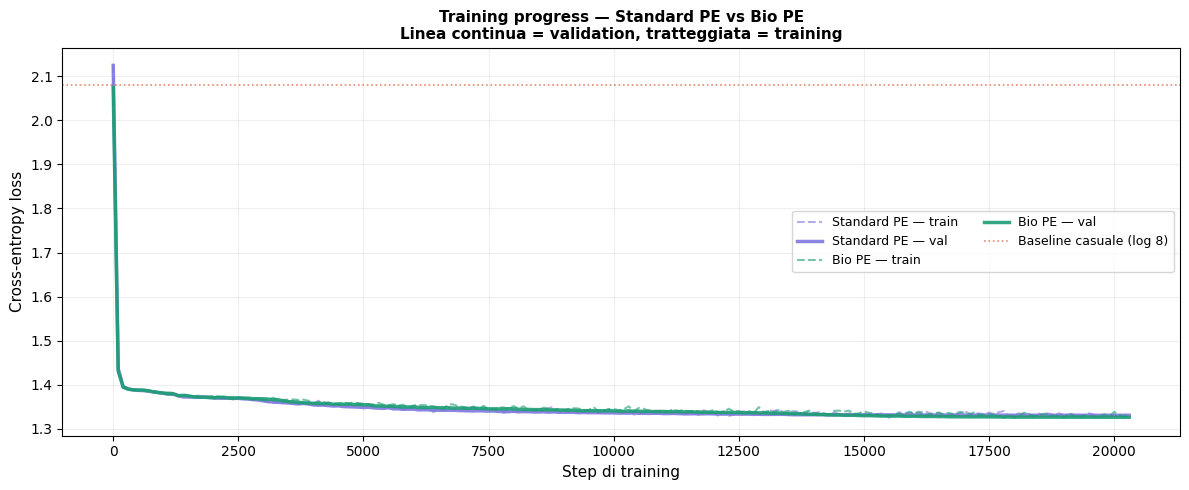

Salvato in figures/training_curves.png


In [60]:
# Curva di training: loss su train e validation per entrambi i modelli
# Utile per verificare che non ci sia overfitting e confrontare le convergenze

fig, ax = plt.subplots(figsize=(12, 5))

color_std  = '#7F77DD'   # viola  — Standard PE
color_bio  = '#1D9E75'   # teal   — Bio PE

for hist, color, label in [
    (history_std, color_std, 'Standard PE'),
    (history_bio, color_bio, 'Bio PE'),
]:
    steps = hist['step']
    ax.plot(steps, hist['train_loss'], color=color, linewidth=1.5,
            linestyle='--', alpha=0.6, label=f'{label} — train')
    ax.plot(steps, hist['val_loss'],   color=color, linewidth=2.5,
            linestyle='-',  alpha=0.9, label=f'{label} — val')

# Linea baseline casuale: log(vocab_size) = log(8) ≈ 2.08
import math
ax.axhline(math.log(config_standard.vocab_size), color='#D85A30',
           linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'Baseline casuale (log {config_standard.vocab_size})')

ax.set_xlabel('Step di training', fontsize=11)
ax.set_ylabel('Cross-entropy loss', fontsize=11)
ax.set_title(
    'Training progress — Standard PE vs Bio PE\n'
    'Linea continua = validation, tratteggiata = training',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/training_curves.png')


## Confronto: Standard PE vs Bio PE

Tre domande:
1. Chi converge più velocemente?
2. Chi raggiunge val loss finale più bassa?
3. Il prior biologico aiuta o è neutro?

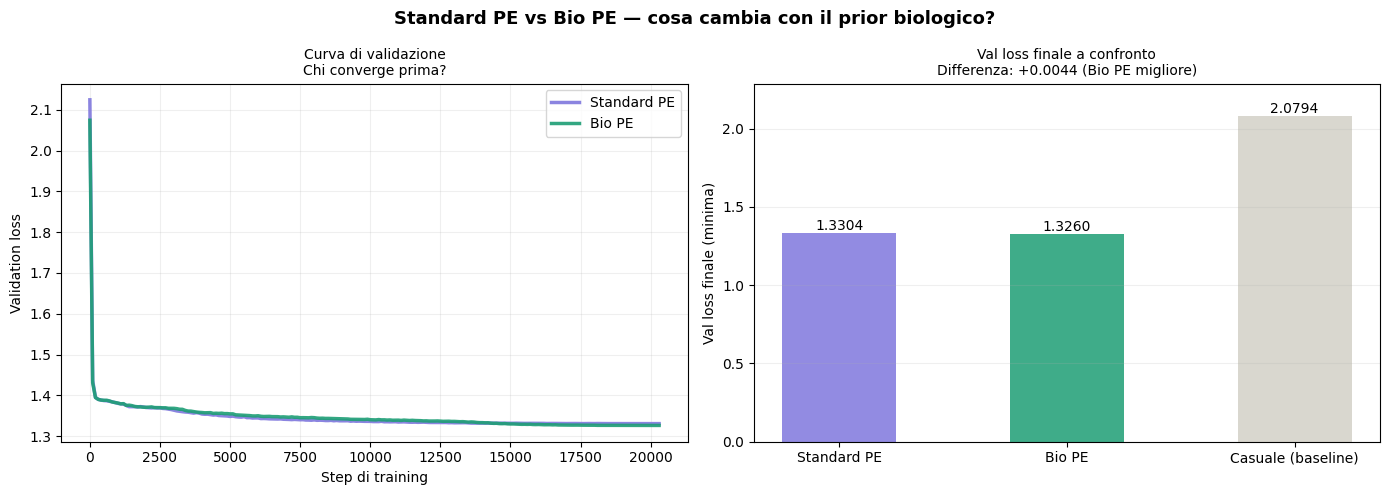

Salvato in figures/comparison_pe.png


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Standard PE vs Bio PE — cosa cambia con il prior biologico?',
    fontsize=13, fontweight='bold'
)

color_std = '#7F77DD'  # viola — Standard PE
color_bio = '#1D9E75'  # teal  — Bio PE

# --- Pannello 1: val loss affiancate ---
ax1 = axes[0]
ax1.plot(history_std['step'], history_std['val_loss'],
         color=color_std, linewidth=2.5, label='Standard PE', alpha=0.9)
ax1.plot(history_bio['step'], history_bio['val_loss'],
         color=color_bio, linewidth=2.5, label='Bio PE', alpha=0.9)

# Evidenzia il punto di convergenza di ciascuno
def convergence_step(history, threshold=0.6):
    """Trova il primo step in cui val loss < threshold * val_loss[0]."""
    v0 = history['val_loss'][0]
    for s, v in zip(history['step'], history['val_loss']):
        if v < v0 * threshold:
            return s, v
    return None, None

for hist, color, name in [
    (history_std, color_std, 'Standard PE'),
    (history_bio, color_bio, 'Bio PE'),
]:
    s, v = convergence_step(hist)
    if s is not None:
        ax1.scatter(s, v, color=color, s=80, zorder=5)
        ax1.annotate(f'{name}\nstep {s}',
                     xy=(s, v), xytext=(s + 50, v + 0.05),
                     fontsize=8, color=color,
                     arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax1.set_xlabel('Step di training')
ax1.set_ylabel('Validation loss')
ax1.set_title('Curva di validazione\nChi converge prima?', fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2)

# --- Pannello 2: barre finali con confronto numerico ---
ax2 = axes[1]

final_std = min(history_std['val_loss'])
final_bio = min(history_bio['val_loss'])
random_loss = math.log(config_standard.vocab_size)

metrics = {
    'Standard PE': final_std,
    'Bio PE':      final_bio,
    'Casuale (baseline)': random_loss,
}
bar_colors = [color_std, color_bio, '#D3D1C7']

bars = ax2.bar(
    list(metrics.keys()), list(metrics.values()),
    color=bar_colors, edgecolor='none', alpha=0.85, width=0.5
)
for bar, val in zip(bars, metrics.values()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.4f}',
        ha='center', fontsize=10, fontweight='500'
    )

delta = final_std - final_bio
ax2.set_ylabel('Val loss finale (minima)')
ax2.set_title(
    f'Val loss finale a confronto\n'
    f'Differenza: {delta:+.4f} '
    f'({"Bio PE migliore" if delta > 0 else "Standard PE migliore" if delta < 0 else "Identici"})',
    fontsize=10
)
ax2.grid(True, alpha=0.2, axis='y')
ax2.set_ylim(0, random_loss * 1.1)

plt.tight_layout()
Path('figures').mkdir(exist_ok=True)
plt.savefig('figures/comparison_pe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/comparison_pe.png')

In [62]:
final_std   = min(history_std['val_loss'])
final_bio   = min(history_bio['val_loss'])
delta       = final_std - final_bio
random_loss = math.log(config_standard.vocab_size)

def steps_to_converge(history, threshold=0.6):
    v0 = history['val_loss'][0]
    for s, v in zip(history['step'], history['val_loss']):
        if v < v0 * threshold:
            return s
    return None

conv_std = steps_to_converge(history_std)
conv_bio = steps_to_converge(history_bio)

print('=' * 55)
print('CONFRONTO STANDARD PE vs BIO PE')
print('=' * 55)
print(f'Val loss finale  — Standard: {final_std:.4f} | Bio: {final_bio:.4f}')
print(f'Riduzione vs casuale — Standard: {(random_loss-final_std)/random_loss*100:.1f}% | Bio: {(random_loss-final_bio)/random_loss*100:.1f}%')
print()

if conv_std and conv_bio:
    print(f'Step a convergenza — Standard: {conv_std} | Bio: {conv_bio}')
    if conv_bio < conv_std:
        print(f'Bio PE converge prima di {conv_std - conv_bio} step.')
    elif conv_std < conv_bio:
        print(f'Standard PE converge prima di {conv_bio - conv_std} step.')
    else:
        print('Velocita di convergenza simile.')
print()


if abs(delta) < 0.01:
    print('CONCLUSIONE: i due modelli sono praticamente equivalenti.')
    print('Il prior biologico nel Bio PE non aggiunge informazione')
    print('che il modello non riesca a imparare da solo dai dati.')
    print()
    print('Questo è un risultato interessante: suggerisce che la')
    print('struttura statistica del genoma e sufficiente a guidare')
    print('l apprendimento, senza bisogno di prior espliciti.')
elif delta > 0.01:
    print('CONCLUSIONE: Bio PE raggiunge loss finale piu bassa.')
    print('Il prior sul codone aiuta il modello ad apprendere')
    print('rappresentazioni piu efficaci delle sequenze genomiche.')
else:
    print('CONCLUSIONE: Standard PE raggiunge loss finale piu bassa.')
    print('Il prior biologico nel Bio PE introduce un bias che')
    print('penalizza l apprendimento — il modello preferisce imparare')
    print('la struttura dai dati piuttosto che da un prior esterno.')
print()
print('Entrambi i modelli sono disponibili per gli esperimenti')
print('nella Sezione 3 di questo notebook come model_std e model_bio.')

CONFRONTO STANDARD PE vs BIO PE
Val loss finale  — Standard: 1.3304 | Bio: 1.3260
Riduzione vs casuale — Standard: 36.0% | Bio: 36.2%


CONCLUSIONE: i due modelli sono praticamente equivalenti.
Il prior biologico nel Bio PE non aggiunge informazione
che il modello non riesca a imparare da solo dai dati.

Questo è un risultato interessante: suggerisce che la
struttura statistica del genoma e sufficiente a guidare
l apprendimento, senza bisogno di prior espliciti.

Entrambi i modelli sono disponibili per gli esperimenti
nella Sezione 3 di questo notebook come model_std e model_bio.


---
## Sezione 3 — Cosa ha Imparato il Modello?


Questa parte del notebook risponde a sei domande biologiche concrete:

> **Esperimento 1 — Shine-Dalgarno:** il modello riconosce il contesto di inizio gene?

> **Esperimento 2 — Sinonimia:** i codoni che codificano lo stesso aminoacido hanno rappresentazioni simili?
>
> **Esperimento 3 — Struttura:** il modello è più sicuro sulle regioni codificanti che su quelle non-codificanti?
>
> **Esperimento 4 — Periodicità:** il modello ha scoperto la struttura a codoni (period-3)?
>
> **Esperimento 5 — Codon Usage Bias:** il modello riflette le preferenze di codone di *E. coli*?
>
> **Esperimento 6 — Generazione:** il modello scrive sequenze biologicamente plausibili?

Utilizzeremo il modello allenato con il Positial Encoding Standard, per evitare qualsiasi bias. In nessun punto abbiamo detto al modello cosa sono i codoni, gli aminoacidi o le CDS.
Se le ha imparate, le ha ricavate dalla struttura statistica del genoma.

In [63]:

config = config_standard
model  = model_std
model.eval()
print(f'Modello: Standard PE  |  vocab_size={config.vocab_size}  |  n_layers={config.n_layers}')


Modello: Standard PE  |  vocab_size=8  |  n_layers=6


In [64]:
# Tabella genetica standard — codone -> aminoacido
GENETIC_CODE = {
    'TTT':'Phe','TTC':'Phe','TTA':'Leu','TTG':'Leu',
    'CTT':'Leu','CTC':'Leu','CTA':'Leu','CTG':'Leu',
    'ATT':'Ile','ATC':'Ile','ATA':'Ile','ATG':'Met',
    'GTT':'Val','GTC':'Val','GTA':'Val','GTG':'Val',
    'TCT':'Ser','TCC':'Ser','TCA':'Ser','TCG':'Ser',
    'CCT':'Pro','CCC':'Pro','CCA':'Pro','CCG':'Pro',
    'ACT':'Thr','ACC':'Thr','ACA':'Thr','ACG':'Thr',
    'GCT':'Ala','GCC':'Ala','GCA':'Ala','GCG':'Ala',
    'TAT':'Tyr','TAC':'Tyr','TAA':'Stop','TAG':'Stop',
    'CAT':'His','CAC':'His','CAA':'Gln','CAG':'Gln',
    'AAT':'Asn','AAC':'Asn','AAA':'Lys','AAG':'Lys',
    'GAT':'Asp','GAC':'Asp','GAA':'Glu','GAG':'Glu',
    'TGT':'Cys','TGC':'Cys','TGA':'Stop','TGG':'Trp',
    'CGT':'Arg','CGC':'Arg','CGA':'Arg','CGG':'Arg',
    'AGT':'Ser','AGC':'Ser','AGA':'Arg','AGG':'Arg',
    'GGT':'Gly','GGC':'Gly','GGA':'Gly','GGG':'Gly',
}

# Colori per aminoacido per caratteristiche chimico-fisiche
AA_COLORS = {
    # Idrofobici — viola
    'Phe':'#534AB7','Leu':'#7F77DD','Ile':'#AFA9EC','Val':'#CECBF6','Met':'#3C3489',
    # Polari — teal
    'Ser':'#1D9E75','Thr':'#5DCAA5','Cys':'#9FE1CB','Asn':'#085041','Gln':'#0F6E56',
    # Carichi pos — corallo
    'Arg':'#D85A30','Lys':'#F0997B','His':'#993C1D',
    # Carichi neg — rosa
    'Asp':'#D4537E','Glu':'#F4C0D1',
    # Speciali
    'Gly':'#888780','Pro':'#444441','Ala':'#D3D1C7',
    # Aromatici — blu
    'Tyr':'#378ADD','Trp':'#0C447C',
    # Stop — nero
    'Stop':'#2C2C2A',
}
print('Setup completato.')

Setup completato.


---
## Esperimento 1 — Il modello riconosce il contesto di inizio gene?

In *E. coli*, la traduzione di un gene non inizia semplicemente al primo ATG.
Il ribosoma si assembla grazie a un segnale preciso a monte dell'ATG:
la **sequenza di Shine-Dalgarno** (tipicamente AGGAGG o simili),
posizionata circa 5–10 nucleotidi prima del codone di start.

```
...AAGGAGGTT----ATG-GCT-AAA-CGT...
   Shine-Dal.  start  ↑
              ~8 nt   codone di inizio
```

Il nostro modello è stato addestrato sull'**intero genoma** di *E. coli*,
quindi ha visto anche le regioni intergeni e le 5'UTR che contengono i siti Shine-Dalgarno.
Statisticamente, ogni ATG di inizio gene è preceduto da una sequenza AGGAGG-like ~8 nt prima.

**Ipotesi:** se il modello ha catturato questa regolarità statistica, i pesi di attenzione
sull'ATG di start dovrebbero essere più alti nella zona -5/-10 nt rispetto all'ATG.

**Come lo misuriamo:**
Nella prima parte del notebook, abbiamo salvato le sequenze `extended_cds`. Ogni CDS con ~50 bp
di contesto upstream, che include la 5'UTR e il potenziale sito Shine-Dalgarno.
Confrontiamo l'attenzione su:
1. **ATG di start** : il codone d'inizio della CDS, alla posizione ~50 della sequenza extended
2. **ATG interno** : un ATG trovato più avanti nella stessa sequenza extended (posizione > 80)

> ⚠️ **Nota metodologica:** gli ATG "interni" nelle sequenze `extended_cds` sono di fatto
> all'inizio della CDS (dopo il contesto upstream), non nel mezzo di un gene lungo.
> Un confronto più rigoroso richiederebbe sequenze CDS complete (> 300 bp) per trovare
> ATG interni genuinamente lontani dall'inizio. Se il risultato è negativo, questo è
> uno dei possibili motivi, oltre brevità del segnale SD (6 bp) e al fatto che
> solo ~50% dei geni di *E. coli* ha un sito SD riconoscibile.


In [141]:
A_ID = tokenizer.vocab['A']
T_ID = tokenizer.vocab['T']
G_ID = tokenizer.vocab['G']

# Le sequenze extended_cds hanno ~50 bp upstream + CDS
# L'ATG di start si trova circa a posizione UPSTREAM nella sequenza tokenizzata
UPSTREAM = 50
START_ATG_MIN = UPSTREAM - 10
START_ATG_MAX = UPSTREAM + 15

WINDOW = 15
MIN_SEQ_LEN = WINDOW * 2 + 5


def find_atg_positions(tokens, min_pos=0):
    """
    Trova tutte le posizioni di ATG come sequenza A,T,G consecutivi.
    Restituisce la posizione di A (primo nucleotide del codone).
    """
    positions = []
    for i in range(min_pos, len(tokens) - 2):
        if tokens[i] == A_ID and tokens[i+1] == T_ID and tokens[i+2] == G_ID:
            positions.append(i)
    return positions


@torch.no_grad()
def get_atg_attention(
    model, tokenizer, sequences,
    atg_position='start',
    n_samples=200,
    window=WINDOW
):
    """
    Raccoglie i pesi di attenzione centrati su ATG (posizione di A).

    Usa sequenze 'extended_cds' che includono ~50 bp di contesto upstream
    (dove si trova il sito Shine-Dalgarno), così il modello ha accesso
    al segnale biologico a monte dell'ATG di start.

    atg_position = 'start'    -> ATG di inizio CDS, preceduto dalla 5'UTR con SD
                                 (posizione ~UPSTREAM nella sequenza tokenizzata)
    atg_position = 'internal' -> ATG nel corpo del gene (posizione > UPSTREAM+350),
                                 senza segnale Shine-Dalgarno a monte
    """
    model.eval()
    collected = []

    for seq in sequences:
        if len(collected) >= n_samples:
            break
        tokens = tokenizer.encode(seq)
        tokens = tokens[:config.context_len]
        if len(tokens) < MIN_SEQ_LEN:
            continue

        if atg_position == 'start':
            # Cerca l'ATG di start nella zona attesa (~posizione UPSTREAM)
            candidates = find_atg_positions(tokens, min_pos=START_ATG_MIN)
            candidates = [p for p in candidates if p <= START_ATG_MAX]
        else:
            # ATG interni: oltre il codone di start
            candidates = find_atg_positions(tokens, min_pos=UPSTREAM + 350)

        if not candidates:
            continue

        atg_pos = candidates[0]


        if atg_pos < window or atg_pos + window >= len(tokens):
            continue


        x = torch.tensor([tokens]).to(device)
        _, _, all_attn = model(x)

        # Pesi di attenzione DA atg_pos VERSO le posizioni circostanti
        sample_attn = []
        for layer_attn in all_attn:
            heads = layer_attn[0, :, atg_pos, :]           # (n_heads, T)
            window_slice = heads[:, atg_pos - window: atg_pos + window + 1]
            sample_attn.append(window_slice.cpu().numpy())  # (n_heads, 2W+1)

        collected.append(np.array(sample_attn))  # (n_layers, n_heads, 2W+1)

    if not collected:
        print(f'Attenzione: nessun campione trovato per atg_position={atg_position}')
        return None

    return np.array(collected)



print('Raccolta attenzione su ATG di start (con contesto Shine-Dalgarno a monte)...')
attn_start = get_atg_attention(
    model, tokenizer, regions['extended_cds'],
    atg_position='start', n_samples=200
)
print('Raccolta attenzione su ATG interni...')
attn_internal = get_atg_attention(
    model, tokenizer, regions['extended_cds'],
    atg_position='internal', n_samples=200
)

if attn_start is not None and attn_internal is not None:
    print(f'Campioni ATG start:    {len(attn_start)}')
    print(f'Campioni ATG interni:  {len(attn_internal)}')

Raccolta attenzione su ATG di start (con contesto Shine-Dalgarno a monte)...
Raccolta attenzione su ATG interni...
Campioni ATG start:    200
Campioni ATG interni:  200


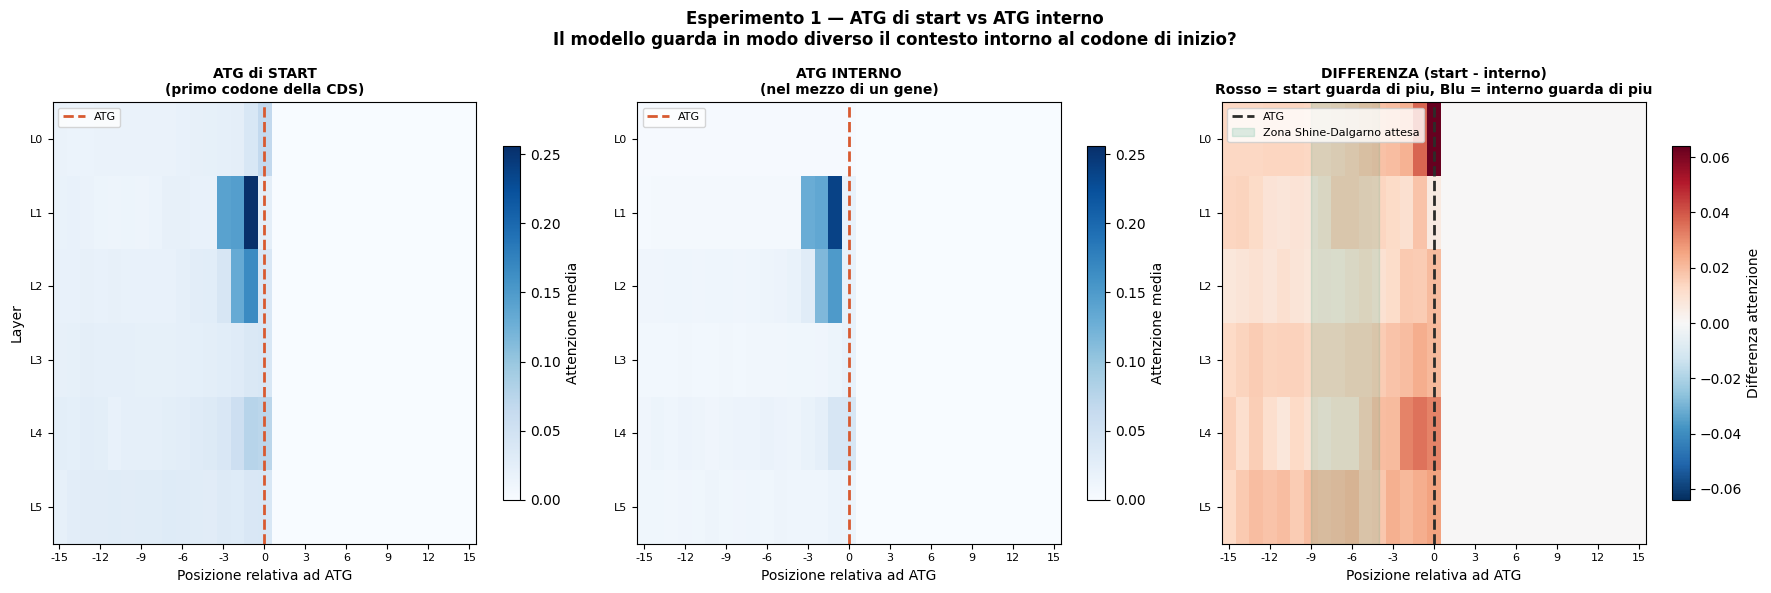

Salvato in figures/exp1_atg_context.png


In [142]:
# Media su tutti i campioni -> (n_layers, n_heads, 2W+1)
mean_start    = attn_start.mean(axis=0)
mean_internal = attn_internal.mean(axis=0)
# Differenza: dove il contesto di start attira attenzione diversa
diff = mean_start - mean_internal

positions = np.arange(-WINDOW, WINDOW + 1)  # da -15 a +15
n_layers  = config.n_layers
n_heads   = config.n_heads

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Esperimento 1 — ATG di start vs ATG interno\n'
    'Il modello guarda in modo diverso il contesto intorno al codone di inizio?',
    fontsize=12, fontweight='bold'
)

# Media su tutti gli head per avere (n_layers, 2W+1)
heatmap_start    = mean_start.mean(axis=1)     # (n_layers, 2W+1)
heatmap_internal = mean_internal.mean(axis=1)  # (n_layers, 2W+1)
heatmap_diff     = diff.mean(axis=1)           # (n_layers, 2W+1)

# --- Pannello 1: ATG start ---
ax1 = axes[0]
im1 = ax1.imshow(
    heatmap_start, aspect='auto', cmap='Blues',
    interpolation='nearest'
)
ax1.axvline(WINDOW, color='#D85A30', linewidth=2, linestyle='--', label='ATG')
ax1.set_xticks(range(0, 2*WINDOW+1, 3))
ax1.set_xticklabels([str(p) for p in positions[::3]], fontsize=8)
ax1.set_yticks(range(n_layers))
ax1.set_yticklabels([f'L{i}' for i in range(n_layers)], fontsize=8)
ax1.set_xlabel('Posizione relativa ad ATG')
ax1.set_ylabel('Layer')
ax1.set_title('ATG di START\n(primo codone della CDS)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
plt.colorbar(im1, ax=ax1, shrink=0.8, label='Attenzione media')

# --- Pannello 2: ATG interno ---
ax2 = axes[1]
im2 = ax2.imshow(
    heatmap_internal, aspect='auto', cmap='Blues',
    interpolation='nearest',
    vmin=im1.get_clim()[0], vmax=im1.get_clim()[1]
)
ax2.axvline(WINDOW, color='#D85A30', linewidth=2, linestyle='--', label='ATG')
ax2.set_xticks(range(0, 2*WINDOW+1, 3))
ax2.set_xticklabels([str(p) for p in positions[::3]], fontsize=8)
ax2.set_yticks(range(n_layers))
ax2.set_yticklabels([f'L{i}' for i in range(n_layers)], fontsize=8)
ax2.set_xlabel('Posizione relativa ad ATG')
ax2.set_title('ATG INTERNO\n(nel mezzo di un gene)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left')
plt.colorbar(im2, ax=ax2, shrink=0.8, label='Attenzione media')

# --- Pannello 3: differenza ---
ax3 = axes[2]
vabs = np.abs(heatmap_diff).max()
im3  = ax3.imshow(
    heatmap_diff, aspect='auto', cmap='RdBu_r',
    interpolation='nearest', vmin=-vabs, vmax=vabs
)
ax3.axvline(WINDOW, color='#2C2C2A', linewidth=2, linestyle='--', label='ATG')


# In k-mer con stride 1: posizioni -8 a -5 corrispondono a indici WINDOW-8 : WINDOW-5
sd_start = WINDOW - 9
sd_end   = WINDOW - 4
ax3.axvspan(sd_start, sd_end, alpha=0.15, color='#1D9E75',
            label='Zona Shine-Dalgarno attesa')

ax3.set_xticks(range(0, 2*WINDOW+1, 3))
ax3.set_xticklabels([str(p) for p in positions[::3]], fontsize=8)
ax3.set_yticks(range(n_layers))
ax3.set_yticklabels([f'L{i}' for i in range(n_layers)], fontsize=8)
ax3.set_xlabel('Posizione relativa ad ATG')
ax3.set_title('DIFFERENZA (start - interno)\nRosso = start guarda di piu, Blu = interno guarda di piu',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=8, loc='upper left')
plt.colorbar(im3, ax=ax3, shrink=0.8, label='Differenza attenzione')

plt.tight_layout()
plt.savefig('figures/exp1_atg_context.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp1_atg_context.png')

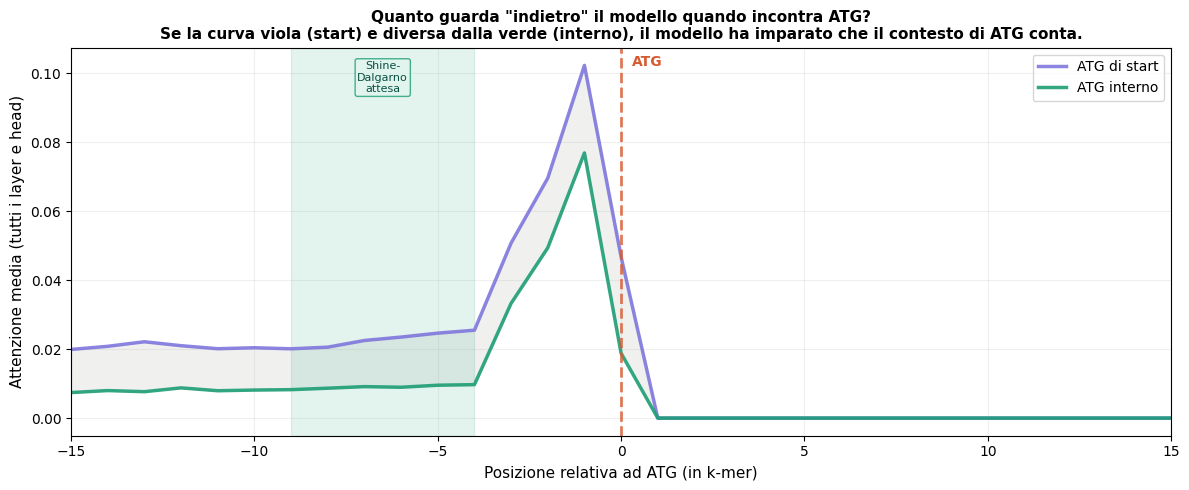

Salvato in figures/exp1_atg_curve.png


In [143]:
# Curva di attenzione media aggregata
# Media su tutti i layer e head
curve_start    = mean_start.mean(axis=(0, 1))
curve_internal = mean_internal.mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(positions, curve_start,    color='#7F77DD', linewidth=2.5,
        label='ATG di start', alpha=0.9)
ax.plot(positions, curve_internal, color='#1D9E75', linewidth=2.5,
        label='ATG interno',  alpha=0.9)
ax.fill_between(positions, curve_start, curve_internal,
                alpha=0.12, color='#888780')


ax.axvline(0, color='#D85A30', linewidth=2, linestyle='--', alpha=0.8)
ax.text(0.3, ax.get_ylim()[1]*0.95, 'ATG', color='#D85A30',
        fontsize=10, fontweight='bold')


ax.axvspan(-9, -4, alpha=0.12, color='#1D9E75')
ax.text(-6.5, ax.get_ylim()[1]*0.88, 'Shine-\nDalgarno\nattesa',
        ha='center', fontsize=8, color='#085041',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#E1F5EE',
                  edgecolor='#1D9E75', alpha=0.8))

ax.set_xlabel('Posizione relativa ad ATG (in k-mer)', fontsize=11)
ax.set_ylabel('Attenzione media (tutti i layer e head)', fontsize=11)
ax.set_title(
    'Quanto guarda "indietro" il modello quando incontra ATG?\n'
    'Se la curva viola (start) e diversa dalla verde (interno), '
    'il modello ha imparato che il contesto di ATG conta.',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_xlim(-WINDOW, WINDOW)

plt.tight_layout()
plt.savefig('figures/exp1_atg_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp1_atg_curve.png')

In [144]:
# Misura quantitativa: la differenza nella zona SD è significativa?

# Zona Shine-Dalgarno: posizioni da -9 a -4 nella finestra
sd_idx = [i for i, p in enumerate(positions) if -9 <= p <= -4]

# Per ogni campione, media attenzione nella zona SD
# attn_start/internal shape: (n_samples, n_layers, n_heads, 2W+1)
sd_attn_start    = attn_start[:, :, :, sd_idx].mean(axis=(1, 2, 3))
sd_attn_internal = attn_internal[:, :, :, sd_idx].mean(axis=(1, 2, 3))

stat, pvalue = stats.mannwhitneyu(
    sd_attn_start, sd_attn_internal, alternative='greater'
)

print('=' * 55)
print('RISULTATO ESPERIMENTO 1')
print('=' * 55)
print()
print('Attenzione media nella zona Shine-Dalgarno (-9 a -4):')
print(f'  ATG di start:   {sd_attn_start.mean():.4f}')
print(f'  ATG interno:    {sd_attn_internal.mean():.4f}')
print(f'  Differenza:     {sd_attn_start.mean() - sd_attn_internal.mean():.4f}')
print(f'  p-value:        {pvalue:.4f}')
print()

if pvalue < 0.05 and sd_attn_start.mean() > sd_attn_internal.mean():
    print('POSITIVO')
    print('Il modello guarda di piu nella zona Shine-Dalgarno')
    print('quando incontra ATG di start rispetto ad ATG interni.')
    print()
    print('Questo suggerisce che il modello ha imparato che il')
    print('contesto a monte di ATG cambia significato biologico —')
    print('senza che nessuno gli abbia mai detto cosa sono i ribosomi e cosa legano.')
elif pvalue < 0.05:
    print('INVERTITO — ATG interno guarda di piu nella zona SD.')
    print('Risultato inatteso, vale la pena analizzare quali layer.')
else:
    print('NEGATIVO — nessuna differenza significativa (p={pvalue:.3f}).')
    print('Il modello tratta ATG di start e ATG interni allo stesso modo.')
    print('Possibili cause: training breve, sequenze CDS troppo simili,')
    print('o il contesto Shine-Dalgarno non compare nei k-mer di training')
    print('(le CDS tipicamente iniziano da ATG, non includono il 5 UTR).')
    print()
    print('Nota: questo ultimo punto e importante —')
    print('se il training e solo su CDS, il modello non ha mai visto')
    print('la sequenza a monte di ATG. La Shine-Dalgarno sta nel 5 UTR.')
    print('Per questo esperimento servirebbero sequenze piu lunghe')
    print('che includano la regione non tradotta a monte.')

RISULTATO ESPERIMENTO 1

Attenzione media nella zona Shine-Dalgarno (-9 a -4):
  ATG di start:   0.0228
  ATG interno:    0.0090
  Differenza:     0.0138
  p-value:        0.0000

POSITIVO
Il modello guarda di piu nella zona Shine-Dalgarno
quando incontra ATG di start rispetto ad ATG interni.

Questo suggerisce che il modello ha imparato che il
contesto a monte di ATG cambia significato biologico —
senza che nessuno gli abbia mai detto cosa sono i ribosomi e cosa legano.


---
## Esperimento 2 — Codoni sinonimi hanno rappresentazioni simili?

Il codice genetico è **ridondante**: 64 possibili triplette (4³ = 64) codificano
solo 20 aminoacidi + codoni di stop. Questo significa che aminoacidi "importanti"
come la Leucina sono codificati da ben 6 triplette diverse:

```
CTT ┐
CTC │
CTA ├─→ Leucina (Leu)  ← stesso aminoacido, sequenza diversa
CTG │
TTA │
TTG ┘
```

Questa ridondanza si chiama **degenerazione** del codice genetico.
**Il modello non conosce aminoacidi** — ha solo letto nucleotidi singoli.
Ma se ha imparato struttura funzionale, le sue rappresentazioni interne
di CTT, CTC, CTA, CTG, TTA, TTG dovrebbero essere più simili tra loro
che alle rappresentazioni di codoni di altri aminoacidi.

**Come lo misuriamo:**
Estraiamo le rappresentazioni dei codoni **in contesto reale** — cioè da sequenze CDS
complete, trovando ogni codone in-frame e catturando l'attivazione al 3° nucleotide
(posizione wobble) in quella sequenza lunga. Questo è fondamentale: il modello è stato
addestrato su sequenze di 512 nucleotidi, non su triplette isolate. Le rappresentazioni
su sequenze corte sarebbero out-of-distribution e non rifletterebbero cosa il modello
ha effettivamente imparato.

Facciamo questo a tre profondità:
- **Layer 0** — primo layer: rappresentazioni quasi grezze
- **Layer intermedio** — metà rete: struttura emergente
- **Layer finale** — ultimo layer: rappresentazioni più astratte

Visualizziamo con **UMAP** e misuriamo con il **silhouette score**.

> ⚠️ **Nota:** il codon usage bias di *E. coli* è molto forte (CTG rappresenta ~50%
> dei codoni Leu nel genoma), quindi ci aspettiamo differenze tra codoni sinonimi
> anche a livello di rappresentazione. La domanda è se queste differenze riflettono
> la struttura aminoacidica o semplicemente la frequenza di uso.


In [94]:
from collections import defaultdict

@torch.no_grad()
def get_codon_reps_in_context(model, tokenizer, regions, layer_idx, n_seqs=500):
    """
    Estrae rappresentazioni dei codoni da sequenze CDS reali (in-frame).

    Per ogni CDS, identifica i codoni in-frame (posizioni 0, 3, 6, ...) e
    cattura l'attivazione al 3° nucleotide di ogni codone.
    Con attenzione causale, la 3a posizione ha visto le prime due → rappresenta
    l'intera tripletta in contesto di sequenza lunga (come durante il training).

    Restituisce dict {codon_str: mean_vector (n_embed,)}
    """
    model.eval()
    codon_reps = defaultdict(list)

    for seq in regions['cds'][:n_seqs]:
        if len(seq) < 30 or len(seq) % 3 != 0:
            continue
        tokens = tokenizer.encode(seq)
        tokens = tokens[:config.context_len]
        if len(tokens) < 10:
            continue
        x = torch.tensor([tokens]).to(device)

        activation = []
        def hook_fn(module, input, output):
            activation.append(output[0].detach().cpu())

        layer = model.blocks[layer_idx]
        handle = layer.register_forward_hook(hook_fn)
        model(x)
        handle.remove()

        act = activation[0][0]  # (T, n_embed)

        # tokens = [BOS, N1, N2, N3, N4, N5, N6, ..., EOS]
        # CDS inizia a tokens[1] (dopo BOS)
        # Codone i: nucleotidi a token pos 1+3i, 1+3i+1, 1+3i+2
        # Il 3° nucleotide del codone i è a posizione 1+3i+2 = 3+3i
        n_codons = (len(seq)) // 3
        for i in range(n_codons):
            pos3 = 1 + 3 * i + 2  # posizione del 3° nucleotide nella sequenza tokenizzata
            if pos3 >= act.shape[0]:
                break
            codon_str = seq[3*i: 3*i+3]
            if len(codon_str) == 3 and all(c in 'ATCG' for c in codon_str):
                codon_reps[codon_str].append(act[pos3].numpy())

    # Media per codone
    result = {}
    for codon, reps in codon_reps.items():
        if len(reps) >= 3:
            result[codon] = np.mean(reps, axis=0)
    return result


# Calcola rappresentazioni ai tre layer di interesse
layer_mid = config.n_layers // 2
layer_fin = config.n_layers - 1

print('Calcolo rappresentazioni triplette in contesto reale (CDS in-frame)...')
reps_by_layer = {}
for name, idx in [('Layer 0 (inizio)', 0),
                   (f'Layer {layer_mid} (metà)', layer_mid),
                   (f'Layer {layer_fin} (fine)', layer_fin)]:
    reps_by_layer[name] = get_codon_reps_in_context(
        model, tokenizer, regions, idx, n_seqs=500
    )
    print(f'  {name} — {len(reps_by_layer[name])} codoni distinti trovati')

codons_common = sorted(
    set(GENETIC_CODE.keys())
    & set.intersection(*[set(reps_by_layer[n].keys()) for n in reps_by_layer])
)
amino_acids   = [GENETIC_CODE[c] for c in codons_common]
gc_contents   = [sum(1 for n in c if n in 'GC') / 3.0 for c in codons_common]
print(f'\nTriplette con rappresentazioni in tutti i layer: {len(codons_common)}/64')

codons = codons_common


Calcolo rappresentazioni triplette in contesto reale (CDS in-frame)...
  Layer 0 (inizio) — 64 codoni distinti trovati
  Layer 3 (metà) — 64 codoni distinti trovati
  Layer 5 (fine) — 64 codoni distinti trovati

Triplette con rappresentazioni in tutti i layer: 64/64


In [70]:

print('Calcolo UMAP per ogni layer...')
umaps_by_layer = {}
for layer_name, reps in reps_by_layer.items():
    vecs = np.array([reps[c] for c in codons])
    reducer = umap.UMAP(n_neighbors=8, min_dist=0.3, random_state=42, n_epochs=500)
    umaps_by_layer[layer_name] = reducer.fit_transform(vecs)
    print(f'  {layer_name} — fatto')

Calcolo UMAP per ogni layer...
  Layer 0 (inizio) — fatto
  Layer 3 (metà) — fatto


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Layer 5 (fine) — fatto


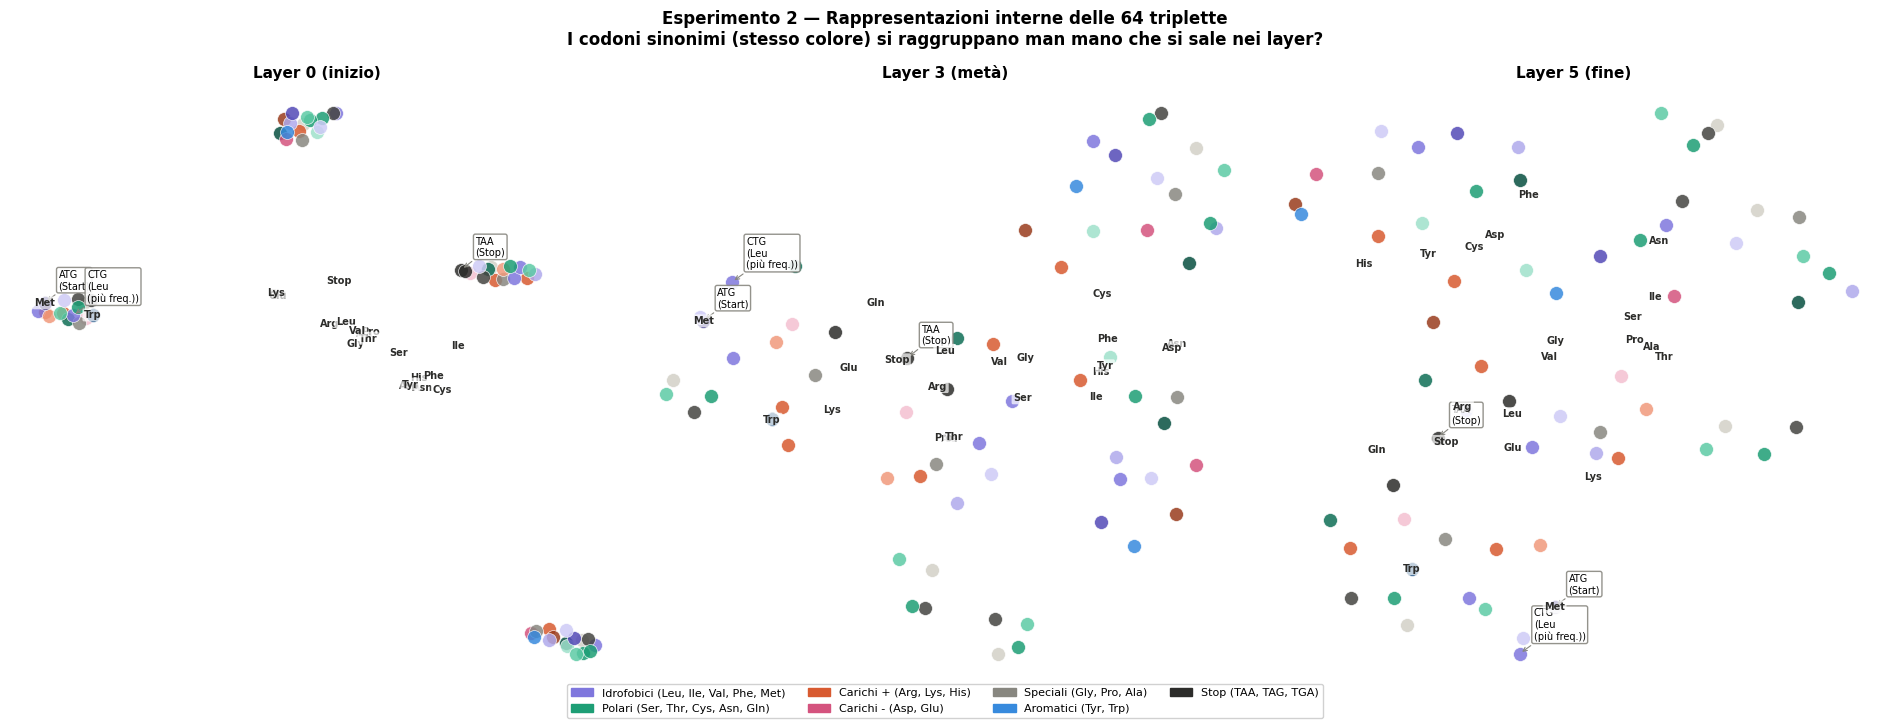

Salvato in figures/exp2_umap_layers.png


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle(
    'Esperimento 2 — Rappresentazioni interne delle 64 triplette\n'
    'I codoni sinonimi (stesso colore) si raggruppano man mano che si sale nei layer?',
    fontsize=12, fontweight='bold'
)

for ax, (layer_name, emb_2d) in zip(axes, umaps_by_layer.items()):


    unique_aas = sorted(set(amino_acids))
    for aa in unique_aas:
        idx   = [i for i, a in enumerate(amino_acids) if a == aa]
        color = AA_COLORS.get(aa, '#888780')
        ax.scatter(
            emb_2d[idx, 0], emb_2d[idx, 1],
            c=color, s=100, alpha=0.85, zorder=3,
            edgecolors='white', linewidths=0.5
        )

        cx = np.mean(emb_2d[idx, 0])
        cy = np.mean(emb_2d[idx, 1])
        ax.text(
            cx, cy, aa,
            fontsize=7, ha='center', va='center',
            fontweight='bold', color='#2C2C2A', zorder=5,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='none', alpha=0.7)
        )


    for codon, label in [
        ('ATG', 'Start'),
        ('TAA', 'Stop'),
        ('CTG', 'Leu\n(più freq.)'),
    ]:
        idx = codons.index(codon)
        ax.annotate(
            f'{codon}\n({label})',
            xy=(emb_2d[idx, 0], emb_2d[idx, 1]),
            xytext=(10, 10), textcoords='offset points',
            fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#888780', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='#888780', lw=0.8)
        )

    ax.set_title(layer_name, fontsize=11, fontweight='bold')
    ax.axis('off')

# Legenda tipo chimico
type_patches = [
    mpatches.Patch(color='#7F77DD', label='Idrofobici (Leu, Ile, Val, Phe, Met)'),
    mpatches.Patch(color='#1D9E75', label='Polari (Ser, Thr, Cys, Asn, Gln)'),
    mpatches.Patch(color='#D85A30', label='Carichi + (Arg, Lys, His)'),
    mpatches.Patch(color='#D4537E', label='Carichi - (Asp, Glu)'),
    mpatches.Patch(color='#888780', label='Speciali (Gly, Pro, Ala)'),
    mpatches.Patch(color='#378ADD', label='Aromatici (Tyr, Trp)'),
    mpatches.Patch(color='#2C2C2A', label='Stop (TAA, TAG, TGA)'),
]
fig.legend(
    handles=type_patches,
    loc='lower center', ncol=4,
    fontsize=8, framealpha=0.9,
    bbox_to_anchor=(0.5, -0.04)
)

plt.tight_layout()
plt.savefig('figures/exp2_umap_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp2_umap_layers.png')

In [97]:
from scipy.spatial.distance import cosine, pdist
from collections import defaultdict

aa_to_codons = defaultdict(list)
for codon, aa in GENETIC_CODE.items():
    aa_to_codons[aa].append(codon)

degenerate_aas = {aa: codons_list
                  for aa, codons_list in aa_to_codons.items()
                  if len(codons_list) >= 2}

print('Aminoacidi con degeneracy (>= 2 codoni):')
for aa, cod in sorted(degenerate_aas.items(), key=lambda x: -len(x[1])):
    print(f'  {aa:4s} — {len(cod)} codoni: {", ".join(cod)}')

Aminoacidi con degeneracy (>= 2 codoni):
  Leu  — 6 codoni: TTA, TTG, CTT, CTC, CTA, CTG
  Ser  — 6 codoni: TCT, TCC, TCA, TCG, AGT, AGC
  Arg  — 6 codoni: CGT, CGC, CGA, CGG, AGA, AGG
  Val  — 4 codoni: GTT, GTC, GTA, GTG
  Pro  — 4 codoni: CCT, CCC, CCA, CCG
  Thr  — 4 codoni: ACT, ACC, ACA, ACG
  Ala  — 4 codoni: GCT, GCC, GCA, GCG
  Gly  — 4 codoni: GGT, GGC, GGA, GGG
  Ile  — 3 codoni: ATT, ATC, ATA
  Stop — 3 codoni: TAA, TAG, TGA
  Phe  — 2 codoni: TTT, TTC
  Tyr  — 2 codoni: TAT, TAC
  His  — 2 codoni: CAT, CAC
  Gln  — 2 codoni: CAA, CAG
  Asn  — 2 codoni: AAT, AAC
  Lys  — 2 codoni: AAA, AAG
  Asp  — 2 codoni: GAT, GAC
  Glu  — 2 codoni: GAA, GAG
  Cys  — 2 codoni: TGT, TGC


In [100]:
# Calcola rappresentazioni per tutti i layer (0..n_layers-1)
print('Calcolo rappresentazioni per tutti i layer...')
all_layer_reps = {}
for layer_idx in range(config.n_layers):
    all_layer_reps[layer_idx] = get_codon_reps_in_context(
        model, tokenizer,regions, layer_idx
    )
    print(f'  Layer {layer_idx} — fatto')

print('Fatto.')

Calcolo rappresentazioni per tutti i layer...
  Layer 0 — fatto
  Layer 1 — fatto
  Layer 2 — fatto
  Layer 3 — fatto
  Layer 4 — fatto
  Layer 5 — fatto
Fatto.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


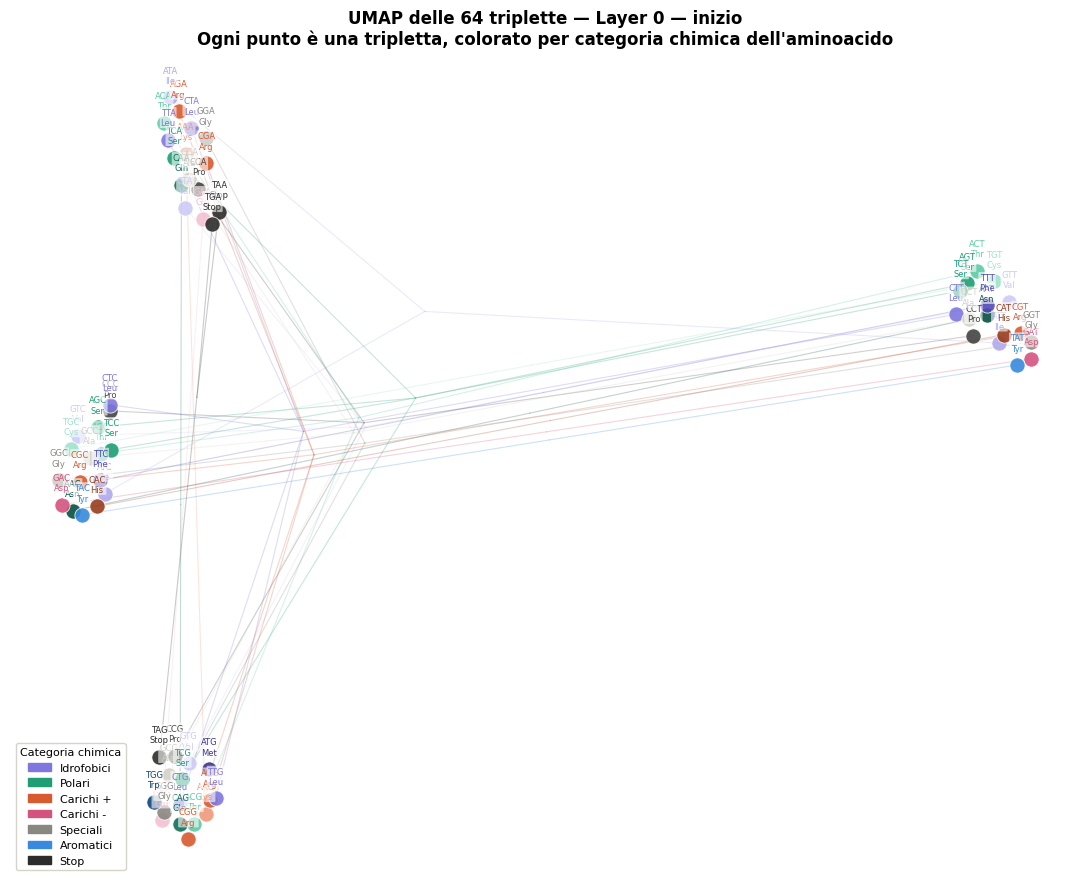

Salvato in figures/exp2_umap_layer0.png


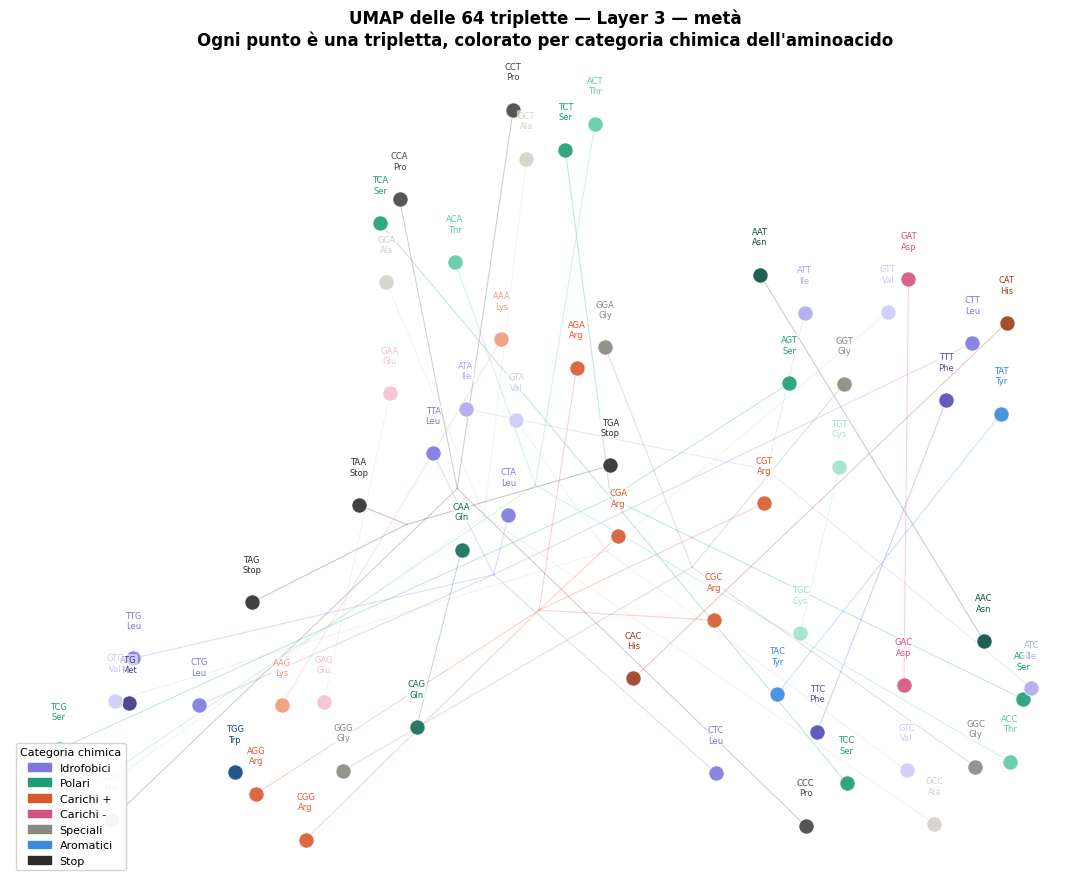

Salvato in figures/exp2_umap_layer3.png


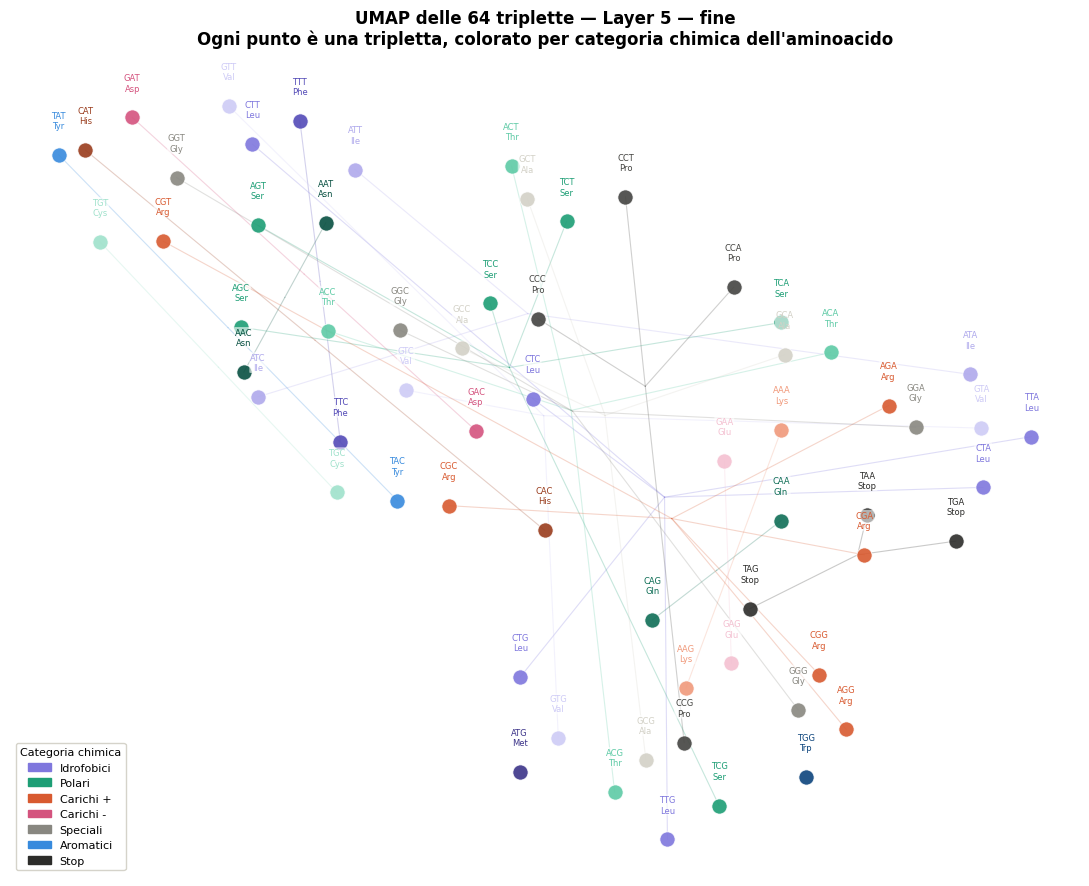

Salvato in figures/exp2_umap_layer5.png


In [101]:
# --- UMAP per layer 0, intermedio, finale ---

layer_mid = config.n_layers // 2
layer_fin = config.n_layers - 1
layers_to_plot = [
    (0,         'Layer 0 — inizio'),
    (layer_mid, f'Layer {layer_mid} — metà'),
    (layer_fin, f'Layer {layer_fin} — fine'),
]

umaps_plot = {}
for layer_idx, _ in layers_to_plot:
    vecs = np.array([all_layer_reps[layer_idx][c] for c in codons])
    reducer = umap.UMAP(n_neighbors=8, min_dist=0.4, random_state=42, n_epochs=500)
    umaps_plot[layer_idx] = reducer.fit_transform(vecs)


for layer_idx, layer_title in layers_to_plot:
    emb_2d = umaps_plot[layer_idx]

    fig, ax = plt.subplots(figsize=(11, 9))
    fig.suptitle(
        f'UMAP delle 64 triplette — {layer_title}\n'
        f'Ogni punto è una tripletta, colorato per categoria chimica dell\'aminoacido',
        fontsize=12, fontweight='bold'
    )

    # Scatter e label per ogni tripletta
    for i, codon in enumerate(codons):
        aa    = amino_acids[i]
        color = AA_COLORS.get(aa, '#888780')
        ax.scatter(
            emb_2d[i, 0], emb_2d[i, 1],
            c=color, s=120, alpha=0.9, zorder=3,
            edgecolors='white', linewidths=0.6
        )
        # Label: tripletta-aminoacido
        ax.text(
            emb_2d[i, 0], emb_2d[i, 1] + 0.25,
            f'{codon}\n{aa}',
            fontsize=6, ha='center', va='bottom',
            color=color, fontweight='500', zorder=5,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                      edgecolor='none', alpha=0.6)
        )


    for aa, syn_list in degenerate_aas.items():
        if len(syn_list) < 2:
            continue
        color = AA_COLORS.get(aa, '#888780')
        idxs  = [codons.index(c) for c in syn_list]
        pts   = emb_2d[idxs]
        # Stella: connetti ogni punto al centroide
        cx, cy = pts.mean(axis=0)
        for px, py in pts:
            ax.plot([px, cx], [py, cy],
                    color=color, alpha=0.25,
                    linewidth=0.8, zorder=2)

    # Legenda
    type_patches = [
        mpatches.Patch(color='#7F77DD', label='Idrofobici'),
        mpatches.Patch(color='#1D9E75', label='Polari'),
        mpatches.Patch(color='#D85A30', label='Carichi +'),
        mpatches.Patch(color='#D4537E', label='Carichi -'),
        mpatches.Patch(color='#888780', label='Speciali'),
        mpatches.Patch(color='#378ADD', label='Aromatici'),
        mpatches.Patch(color='#2C2C2A', label='Stop'),
    ]
    ax.legend(
        handles=type_patches,
        loc='lower left', fontsize=8,
        framealpha=0.95, edgecolor='#D3D1C7',
        title='Categoria chimica', title_fontsize=8
    )
    ax.axis('off')

    fname = f'figures/exp2_umap_layer{layer_idx}.png'
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvato in {fname}')

In [102]:
# Calcola distanza media tra sinonimi per ogni aa e ogni layer
# shape risultante: {aa: [dist_layer0, dist_layer1, ..., dist_layerN]}

def mean_synonymous_distance(reps, codon_list):
    """
    Distanza coseno media tra tutte le coppie di codoni sinonimi.
    Con N codoni ci sono N*(N-1)/2 coppie.
    Restituisce 0 se c'è un solo codone.
    """
    if len(codon_list) < 2:
        return 0.0
    vecs = np.array([reps[c] for c in codon_list])
    # pdist calcola tutte le distanze a coppie
    dists = pdist(vecs, metric='cosine')
    return float(dists.mean())


n_layers    = config.n_layers
layer_range = list(range(n_layers))

distances = {}  # {aa: [dist per ogni layer]}
for aa, syn_list in aa_to_codons.items():
    distances[aa] = [
        mean_synonymous_distance(all_layer_reps[l], syn_list)
        for l in layer_range
    ]

print('Distanza media sinonimi per aminoacido (layer 0 → finale):')
print(f'{"AA":<6} {" ".join(f"L{l}" for l in layer_range)}')
for aa in sorted(distances):
    vals = '  '.join(f'{v:.3f}' for v in distances[aa])
    n    = len(aa_to_codons[aa])
    print(f'{aa:<6} {vals}  ({n} codoni)')

Distanza media sinonimi per aminoacido (layer 0 → finale):
AA     L0 L1 L2 L3 L4 L5
Ala    0.553  0.480  0.473  0.532  0.467  0.098  (4 codoni)
Arg    0.493  0.514  0.584  0.608  0.478  0.105  (6 codoni)
Asn    0.629  0.396  0.336  0.359  0.271  0.059  (2 codoni)
Asp    0.608  0.386  0.441  0.461  0.396  0.105  (2 codoni)
Cys    0.616  0.387  0.421  0.385  0.288  0.068  (2 codoni)
Gln    0.552  0.427  0.425  0.505  0.404  0.097  (2 codoni)
Glu    0.537  0.437  0.395  0.504  0.458  0.121  (2 codoni)
Gly    0.543  0.396  0.358  0.502  0.480  0.123  (4 codoni)
His    0.612  0.355  0.374  0.433  0.381  0.106  (2 codoni)
Ile    0.569  0.425  0.359  0.414  0.362  0.075  (3 codoni)
Leu    0.485  0.482  0.524  0.582  0.559  0.165  (6 codoni)
Lys    0.561  0.500  0.347  0.419  0.310  0.059  (2 codoni)
Met    0.000  0.000  0.000  0.000  0.000  0.000  (1 codoni)
Phe    0.626  0.492  0.493  0.564  0.411  0.079  (2 codoni)
Pro    0.565  0.506  0.453  0.483  0.412  0.096  (4 codoni)
Ser    0.501  0.

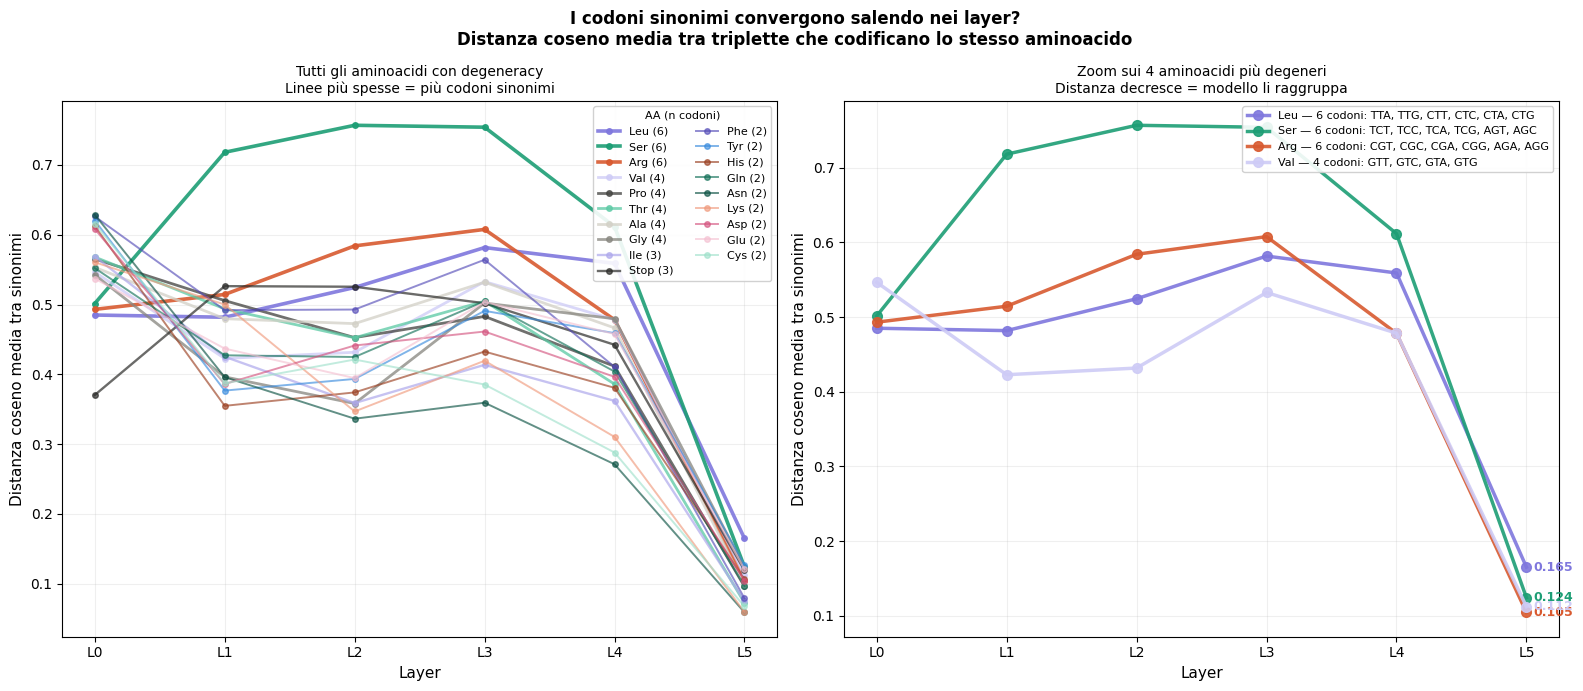

Salvato in figures/exp2_synonymous_distance_by_layer.png


In [107]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'I codoni sinonimi convergono salendo nei layer?\n'
    'Distanza coseno media tra triplette che codificano lo stesso aminoacido',
    fontsize=12, fontweight='bold'
)

# --- Pannello 1: tutti gli aminoacidi degeneri ---
ax1 = axes[0]

# Ordina per numero di codoni
sorted_aas = sorted(
    degenerate_aas.keys(),
    key=lambda aa: -len(degenerate_aas[aa])
)

for aa in sorted_aas:
    n_codons = len(degenerate_aas[aa])
    color    = AA_COLORS.get(aa, '#888780')
    dists    = distances[aa]

    # Spessore linea proporzionale al numero di codoni
    lw     = 0.8 + (n_codons / 6) * 1.8
    alpha  = 0.5 + (n_codons / 6) * 0.4

    ax1.plot(
        layer_range, dists,
        color=color, linewidth=lw, alpha=alpha,
        marker='o', markersize=4, label=f'{aa} ({n_codons})'
    )

ax1.set_xlabel('Layer', fontsize=11)
ax1.set_ylabel('Distanza coseno media tra sinonimi', fontsize=11)
ax1.set_title(
    'Tutti gli aminoacidi con degeneracy\n'
    'Linee più spesse = più codoni sinonimi',
    fontsize=10
)
ax1.set_xticks(layer_range)
ax1.set_xticklabels([f'L{l}' for l in layer_range])
ax1.legend(
    fontsize=8, ncol=2,
    loc='upper right',
    title='AA (n codoni)', title_fontsize=8,
    framealpha=0.9
)
ax1.grid(True, alpha=0.2)

# --- Pannello 2: zoom sui 4 più degeneri ---
ax2 = axes[1]
top4 = sorted_aas[:4]  # i 4 con più codoni sinonimi

for aa in top4:
    n_codons = len(degenerate_aas[aa])
    color    = AA_COLORS.get(aa, '#888780')
    dists    = distances[aa]

    ax2.plot(
        layer_range, dists,
        color=color, linewidth=2.5, alpha=0.9,
        marker='o', markersize=7,
        label=f'{aa} — {n_codons} codoni: {", ".join(degenerate_aas[aa])}'
    )

    # Annota il valore al layer finale
    ax2.annotate(
        f'{dists[-1]:.3f}',
        xy=(layer_range[-1], dists[-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold', va='center'
    )

ax2.set_xlabel('Layer', fontsize=11)
ax2.set_ylabel('Distanza coseno media tra sinonimi', fontsize=11)
ax2.set_title(
    'Zoom sui 4 aminoacidi più degeneri\n'
    'Distanza decresce = modello li raggruppa',
    fontsize=10
)
ax2.set_xticks(layer_range)
ax2.set_xticklabels([f'L{l}' for l in layer_range])
ax2.legend(fontsize=8, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/exp2_synonymous_distance_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp2_synonymous_distance_by_layer.png')

In [109]:
# Calcola distanza media tra NON-sinonimi per ogni aa e ogni layer
# Per ogni aminoacido: distanza media tra i suoi codoni e tutti gli altri

aa_map = {codon: aa for codon, aa in GENETIC_CODE.items()}

def mean_nonsynonymous_distance_aa(reps, codon_list, aa):
    """
    Distanza media tra i codoni di un aminoacido
    e tutti i codoni di aminoacidi diversi.
    """
    other_codons = [c for c, a in aa_map.items() if a != aa]

    dists = []
    for c_syn in codon_list:
        v_syn = reps[c_syn]
        for c_other in other_codons:
            dists.append(cosine(v_syn, reps[c_other]))
    return float(np.mean(dists))

distances_nonsyn = {}
for aa, syn_list in degenerate_aas.items():
    distances_nonsyn[aa] = [
        mean_nonsynonymous_distance_aa(all_layer_reps[l], syn_list, aa)
        for l in layer_range
    ]



Fatto.


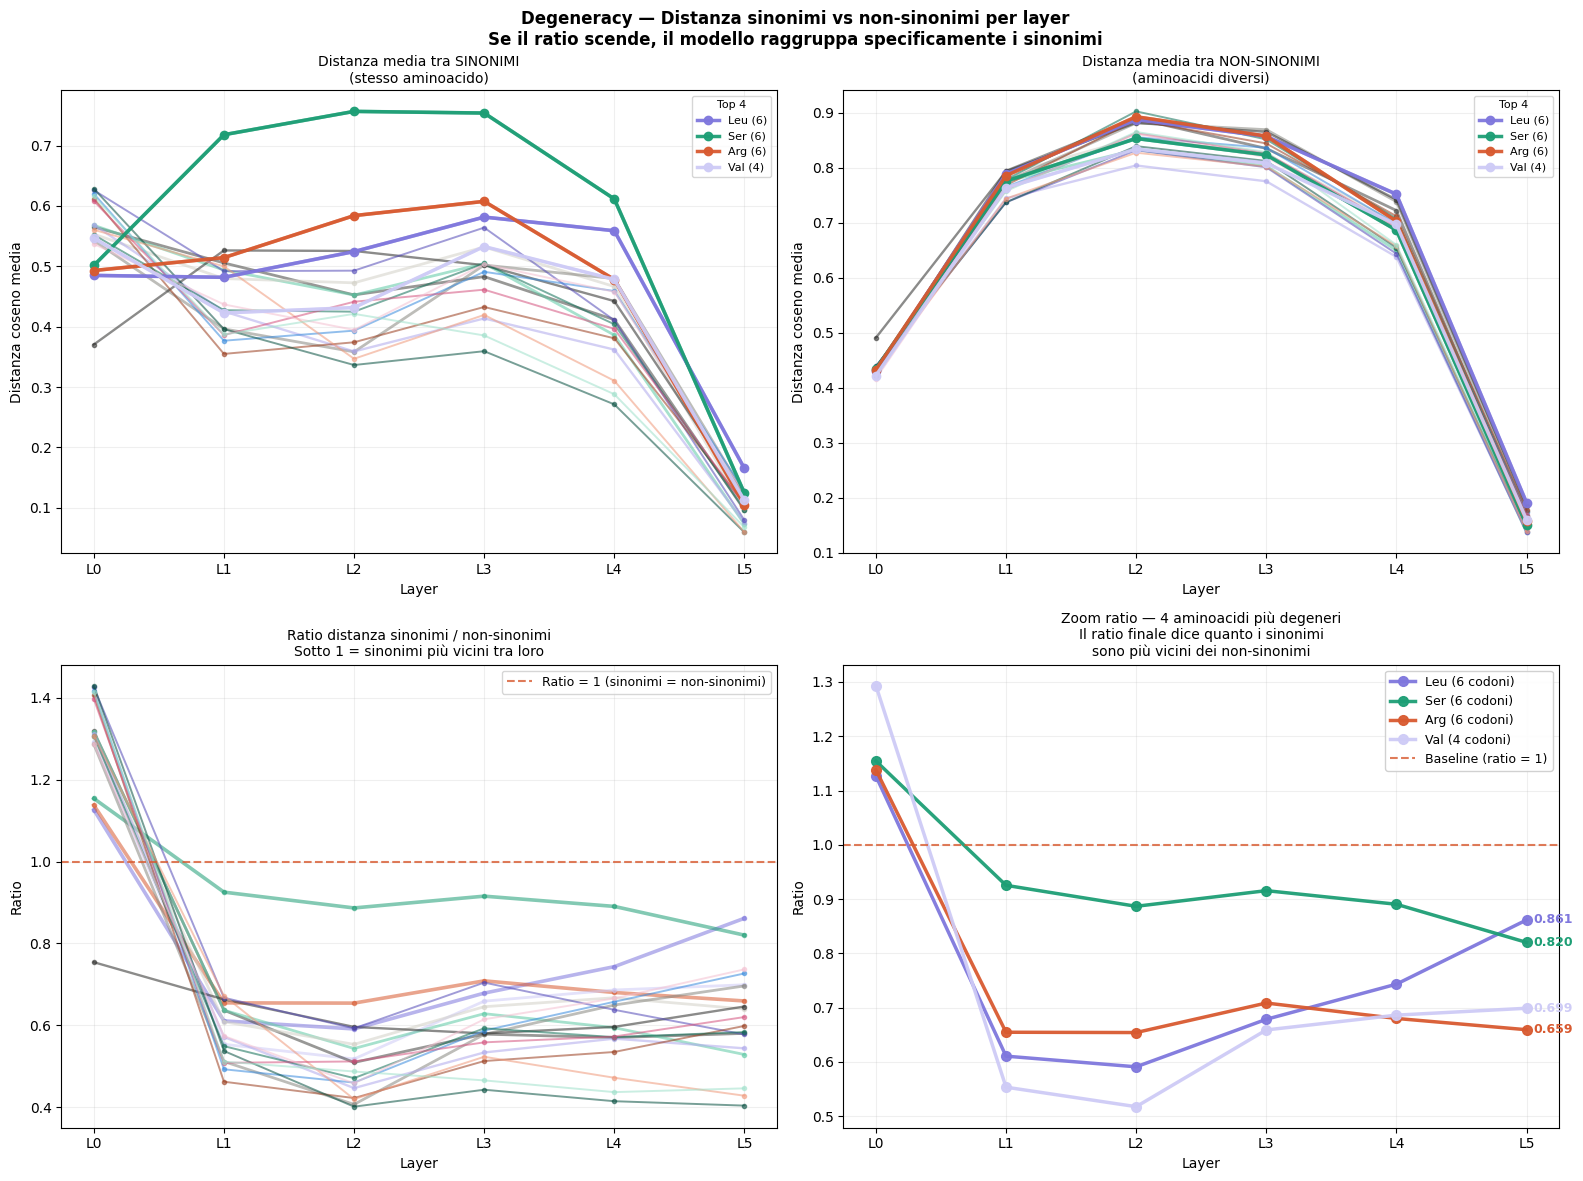

Salvato in figures/exp2_syn_vs_nonsyn.png


In [110]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Degeneracy — Distanza sinonimi vs non-sinonimi per layer\n'
    'Se il ratio scende, il modello raggruppa specificamente i sinonimi',
    fontsize=12, fontweight='bold'
)

ax_syn    = axes[0, 0]
ax_nonsyn = axes[0, 1]
ax_ratio  = axes[1, 0]
ax_zoom   = axes[1, 1]

top4 = sorted(
    degenerate_aas.keys(),
    key=lambda aa: -len(degenerate_aas[aa])
)[:4]

# Palette condivisa per i 4 più degeneri
top4_colors = {aa: AA_COLORS.get(aa, '#888780') for aa in top4}

# --- Pannello 1: distanza sinonimi ---
for aa in sorted_aas:
    color = AA_COLORS.get(aa, '#888780')
    n     = len(degenerate_aas[aa])
    lw    = 0.8 + (n / 6) * 1.8
    ax_syn.plot(
        layer_range, distances[aa],
        color=color, linewidth=lw, alpha=0.55,
        marker='o', markersize=3
    )
# Evidenzia top4
for aa in top4:
    ax_syn.plot(
        layer_range, distances[aa],
        color=top4_colors[aa], linewidth=2.5,
        alpha=0.95, marker='o', markersize=6,
        label=f'{aa} ({len(degenerate_aas[aa])})'
    )

ax_syn.set_title('Distanza media tra SINONIMI\n(stesso aminoacido)', fontsize=10)
ax_syn.set_xlabel('Layer')
ax_syn.set_ylabel('Distanza coseno media')
ax_syn.set_xticks(layer_range)
ax_syn.set_xticklabels([f'L{l}' for l in layer_range])
ax_syn.legend(fontsize=8, title='Top 4', title_fontsize=8)
ax_syn.grid(True, alpha=0.2)

# --- Pannello 2: distanza non-sinonimi ---
for aa in sorted_aas:
    color = AA_COLORS.get(aa, '#888780')
    n     = len(degenerate_aas[aa])
    lw    = 0.8 + (n / 6) * 1.8
    ax_nonsyn.plot(
        layer_range, distances_nonsyn[aa],
        color=color, linewidth=lw, alpha=0.55,
        marker='o', markersize=3
    )
for aa in top4:
    ax_nonsyn.plot(
        layer_range, distances_nonsyn[aa],
        color=top4_colors[aa], linewidth=2.5,
        alpha=0.95, marker='o', markersize=6,
        label=f'{aa} ({len(degenerate_aas[aa])})'
    )

ax_nonsyn.set_title('Distanza media tra NON-SINONIMI\n(aminoacidi diversi)', fontsize=10)
ax_nonsyn.set_xlabel('Layer')
ax_nonsyn.set_ylabel('Distanza coseno media')
ax_nonsyn.set_xticks(layer_range)
ax_nonsyn.set_xticklabels([f'L{l}' for l in layer_range])
ax_nonsyn.legend(fontsize=8, title='Top 4', title_fontsize=8)
ax_nonsyn.grid(True, alpha=0.2)

# --- Pannello 3: ratio sinonimi / non-sinonimi (tutti) ---
# Ratio < 1 significa che i sinonimi sono più vicini dei non-sinonimi
# Ratio che scende = il modello li raggruppa progressivamente
for aa in sorted_aas:
    color = AA_COLORS.get(aa, '#888780')
    n     = len(degenerate_aas[aa])
    lw    = 0.8 + (n / 6) * 1.8
    ratio = [
        s / ns if ns > 0 else 1.0
        for s, ns in zip(distances[aa], distances_nonsyn[aa])
    ]
    ax_ratio.plot(
        layer_range, ratio,
        color=color, linewidth=lw, alpha=0.55,
        marker='o', markersize=3
    )

ax_ratio.axhline(
    1.0, color='#D85A30', linestyle='--',
    linewidth=1.5, alpha=0.8,
    label='Ratio = 1 (sinonimi = non-sinonimi)'
)
ax_ratio.set_title(
    'Ratio distanza sinonimi / non-sinonimi\n'
    'Sotto 1 = sinonimi più vicini tra loro',
    fontsize=10
)
ax_ratio.set_xlabel('Layer')
ax_ratio.set_ylabel('Ratio')
ax_ratio.set_xticks(layer_range)
ax_ratio.set_xticklabels([f'L{l}' for l in layer_range])
ax_ratio.legend(fontsize=9)
ax_ratio.grid(True, alpha=0.2)

# --- Pannello 4: zoom ratio top4 con annotazioni ---
for aa in top4:
    ratio = [
        s / ns if ns > 0 else 1.0
        for s, ns in zip(distances[aa], distances_nonsyn[aa])
    ]
    ax_zoom.plot(
        layer_range, ratio,
        color=top4_colors[aa], linewidth=2.5,
        alpha=0.95, marker='o', markersize=7,
        label=f'{aa} ({len(degenerate_aas[aa])} codoni)'
    )
    ax_zoom.annotate(
        f'{ratio[-1]:.3f}',
        xy=(layer_range[-1], ratio[-1]),
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, color=top4_colors[aa],
        fontweight='bold', va='center'
    )

ax_zoom.axhline(
    1.0, color='#D85A30', linestyle='--',
    linewidth=1.5, alpha=0.8,
    label='Baseline (ratio = 1)'
)
ax_zoom.set_title(
    'Zoom ratio — 4 aminoacidi più degeneri\n'
    'Il ratio finale dice quanto i sinonimi\n'
    'sono più vicini dei non-sinonimi',
    fontsize=10
)
ax_zoom.set_xlabel('Layer')
ax_zoom.set_ylabel('Ratio')
ax_zoom.set_xticks(layer_range)
ax_zoom.set_xticklabels([f'L{l}' for l in layer_range])
ax_zoom.legend(fontsize=9, framealpha=0.9)
ax_zoom.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/exp2_syn_vs_nonsyn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp2_syn_vs_nonsyn.png')

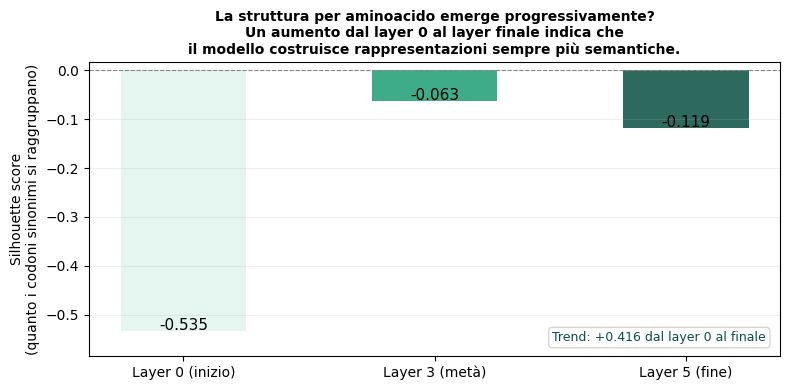

Salvato in figures/exp2_silhouette_by_layer.png


In [111]:
# Misura quantitativa: silhouette score per layer
# Misura quanto i codoni dello stesso aminoacido sono vicini
# rispetto a codoni di aminoacidi diversi.
# Score vicino a 1 = cluster compatti e separati
# Score vicino a 0 = nessuna struttura

le     = LabelEncoder()
labels = le.fit_transform(amino_acids)

sil_scores = {}
for layer_name, reps in reps_by_layer.items():
    vecs = np.array([reps[c] for c in codons])
    sil  = silhouette_score(vecs, labels, metric='cosine')
    sil_scores[layer_name] = sil

# Plot silhouette per layer
fig, ax = plt.subplots(figsize=(8, 4))

layer_names = list(sil_scores.keys())
sil_vals    = list(sil_scores.values())
colors_bar  = ['#E1F5EE', '#1D9E75', '#085041']

bars = ax.bar(
    range(len(layer_names)), sil_vals,
    color=colors_bar, edgecolor='none',
    alpha=0.85, width=0.5
)
for bar, val in zip(bars, sil_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center', fontsize=11, fontweight='500'
    )

ax.set_xticks(range(len(layer_names)))
ax.set_xticklabels(layer_names, fontsize=10)
ax.set_ylabel('Silhouette score\n(quanto i codoni sinonimi si raggruppano)', fontsize=10)
ax.set_title(
    'La struttura per aminoacido emerge progressivamente?\n'
    'Un aumento dal layer 0 al layer finale indica che\n'
    'il modello costruisce rappresentazioni sempre più semantiche.',
    fontsize=10, fontweight='bold'
)
ax.axhline(0, color='#888780', linewidth=0.8, linestyle='--')
ax.set_ylim(min(sil_vals) - 0.05, max(sil_vals) + 0.08)
ax.grid(True, alpha=0.2, axis='y')


trend = sil_vals[-1] - sil_vals[0]
trend_label = (
    f'Trend: +{trend:.3f} dal layer 0 al finale'
    if trend > 0
    else f'Trend: {trend:.3f} — struttura non aumenta con la profondità'
)
ax.text(
    0.98, 0.05, trend_label,
    transform=ax.transAxes, ha='right', fontsize=9,
    color='#085041' if trend > 0 else '#D85A30',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor='#D3D1C7', alpha=0.9)
)

plt.tight_layout()
plt.savefig('figures/exp2_silhouette_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp2_silhouette_by_layer.png')

In [112]:
from scipy.stats import wilcoxon, mannwhitneyu
import matplotlib.ticker as ticker

# Per ogni codone calcola:
# - distanza media verso i propri sinonimi
# - distanza media verso tutti i non-sinonimi

def per_codon_distances(reps):
    """
    Per ogni codone restituisce:
      syn_dist:    distanza media verso i suoi sinonimi (NaN se codone unico)
      nonsyn_dist: distanza media verso tutti i codoni di aa diverso
    """
    syn_dists    = []
    nonsyn_dists = []
    codon_labels = []

    for codon in GENETIC_CODE.keys():
        aa         = GENETIC_CODE[codon]
        synonyms   = [c for c, a in GENETIC_CODE.items() if a == aa and c != codon]
        nonsynonyms = [c for c, a in GENETIC_CODE.items() if a != aa]

        v = reps[codon]

        # Distanza verso sinonimi
        if synonyms:
            d_syn = np.mean([cosine(v, reps[s]) for s in synonyms])
        else:
            d_syn = np.nan  # Met e Trp

        # Distanza verso non-sinonimi
        d_nonsyn = np.mean([cosine(v, reps[s]) for s in nonsynonyms])

        syn_dists.append(d_syn)
        nonsyn_dists.append(d_nonsyn)
        codon_labels.append(codon)

    return np.array(syn_dists), np.array(nonsyn_dists), codon_labels

per_layer = {}
for l in layer_range:
    syn, nonsyn, labels = per_codon_distances(all_layer_reps[l])
    per_layer[l] = {'syn': syn, 'nonsyn': nonsyn, 'labels': labels}

print('Dati per boxplot calcolati.')
print(f'Codoni per gruppo: {(~np.isnan(per_layer[0]["syn"])).sum()} (con sinonimi)')

Dati per boxplot calcolati.
Codoni per gruppo: 62 (con sinonimi)


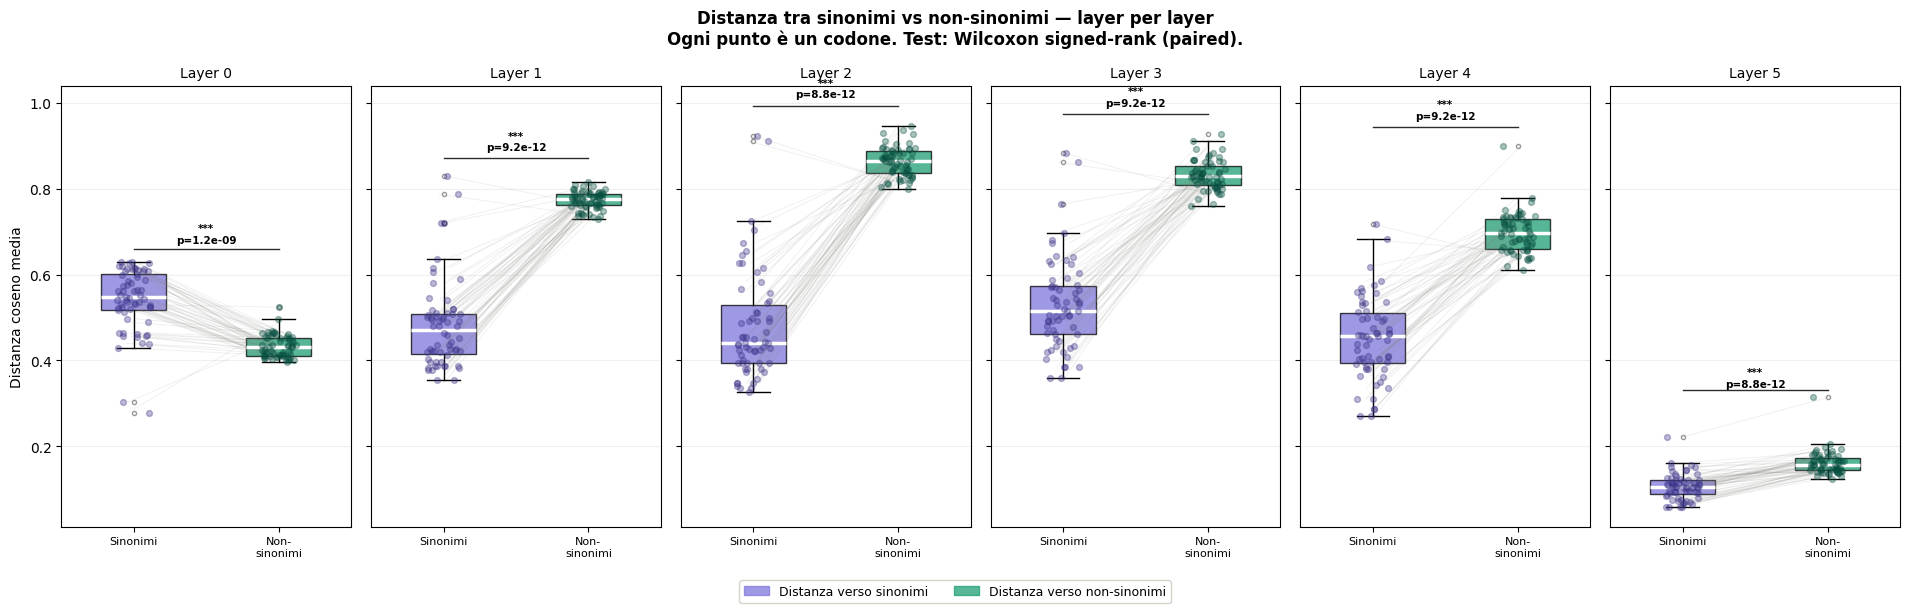

Salvato in figures/exp2_boxplot_by_layer.png


In [115]:
n_layers = config.n_layers
fig, axes = plt.subplots(
    1, n_layers,
    figsize=(3.2 * n_layers, 6),
    sharey=True
)
fig.suptitle(
    'Distanza tra sinonimi vs non-sinonimi — layer per layer\n'
    'Ogni punto è un codone. Test: Wilcoxon signed-rank (paired).',
    fontsize=12, fontweight='bold'
)

for l, ax in enumerate(axes):

    syn_vals    = per_layer[l]['syn']
    nonsyn_vals = per_layer[l]['nonsyn']


    mask        = ~np.isnan(syn_vals)
    syn_clean   = syn_vals[mask]
    nonsyn_clean = nonsyn_vals[mask]

    bp = ax.boxplot(
        [syn_clean, nonsyn_clean],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        widths=0.45,
        positions=[1, 2]
    )
    bp['boxes'][0].set_facecolor('#7F77DD')
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor('#1D9E75')
    bp['boxes'][1].set_alpha(0.75)

    np.random.seed(42)
    for pos, vals, color in [
        (1, syn_clean,   '#3C3489'),
        (2, nonsyn_clean,'#085041'),
    ]:
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(
            np.full(len(vals), pos) + jitter,
            vals,
            alpha=0.35, s=18, color=color, zorder=3
        )

    for s, ns, in zip(syn_clean, nonsyn_clean):
        ax.plot(
            [1 + np.random.uniform(-0.05, 0.05),
             2 + np.random.uniform(-0.05, 0.05)],
            [s, ns],
            color='#888780', alpha=0.12, linewidth=0.7, zorder=2
        )

    stat, pval = wilcoxon(syn_clean, nonsyn_clean)
    y_max = max(syn_clean.max(), nonsyn_clean.max())
    y_bar = y_max * 1.05
    ax.plot([1, 2], [y_bar, y_bar], color='#2C2C2A', linewidth=1)
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'n.s.'
    ax.text(
        1.5, y_bar * 1.02,
        f'{sig}\np={pval:.1e}',
        ha='center', fontsize=7.5,
        fontweight='bold' if sig != 'n.s.' else 'normal'
    )

    ax.set_title(f'Layer {l}', fontsize=10, fontweight='500')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sinonimi', 'Non-\nsinonimi'], fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

    if l == 0:
        ax.set_ylabel('Distanza coseno media', fontsize=10)


syn_patch    = mpatches.Patch(color='#7F77DD', alpha=0.75, label='Distanza verso sinonimi')
nonsyn_patch = mpatches.Patch(color='#1D9E75', alpha=0.75, label='Distanza verso non-sinonimi')
fig.legend(
    handles=[syn_patch, nonsyn_patch],
    loc='lower center', ncol=2,
    fontsize=9, bbox_to_anchor=(0.5, -0.02),
    framealpha=0.95, edgecolor='#D3D1C7'
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('figures/exp2_boxplot_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp2_boxplot_by_layer.png')

---
## Esperimento 3 — Il modello è più sicuro sulle CDS?

**Ipotesi:** le regioni codificanti (CDS) hanno una struttura più regolare:
frame del codone conservato, codon bias specifico di *E. coli*, segnali di inizio e fine.
Il modello dovrebbe predire meglio queste regioni rispetto agli spazi intergeni,
che sono più casuali.

**Come misuriamo:** la **perplexity**, calcolata come exp(cross-entropy loss).
Intuitivamente: perplexity = K significa che il modello è mediamente incerto
tra K scelte ugualmente probabili al passo successivo.

- **Perplexity = 1** → il modello predice sempre il nucleotide corretto (perfetto)
- **Perplexity = 8** → baseline casuale su questo vocabolario (8 token: A, T, C, G + speciali)
- **Perplexity bassa** → il modello è sicuro → la sequenza è statisticamente regolare
- **Perplexity alta** → il modello è sorpreso → la sequenza è più casuale

Se il modello ha imparato la struttura biologica, le CDS dovrebbero avere
perplexity significativamente più bassa delle regioni non-codificanti.


In [117]:
@torch.no_grad()
def compute_perplexity(model, tokenizer, sequences, max_len=180):
    """Calcola perplexity per ogni sequenza. Restituisce lista di float."""
    model.eval()
    results = []
    for seq in sequences:
        tokens = tokenizer.encode(seq[:max_len + 3])[:max_len]
        if len(tokens) < 12:
            continue
        x = torch.tensor([tokens[:-1]]).to(device)
        y = torch.tensor([tokens[1:]]).to(device)
        logits, _, _ = model(x)
        loss = F.cross_entropy(
            logits.view(-1, config.vocab_size),
            y.view(-1),
            ignore_index=0
        )
        ppl = math.exp(min(loss.item(), 10))
        results.append(ppl)
    return results


print('Calcolo perplexity su CDS...')
cds_ppl = compute_perplexity(model, tokenizer, regions['cds'][:400])
print('Calcolo perplexity su regioni non-codificanti...')
nc_ppl  = compute_perplexity(model, tokenizer, regions['non_coding'][:400])
stat, pvalue = stats.mannwhitneyu(cds_ppl, nc_ppl, alternative='less')

print(f'\nCDS           — media: {np.mean(cds_ppl):.2f} ± {np.std(cds_ppl):.2f}')
print(f'Non-coding    — media: {np.mean(nc_ppl):.2f} ± {np.std(nc_ppl):.2f}')
print(f'Differenza    — {np.mean(nc_ppl) - np.mean(cds_ppl):.2f}')
print(f'Mann-Whitney p-value: {pvalue:.4f}')

Calcolo perplexity su CDS...
Calcolo perplexity su regioni non-codificanti...

CDS           — media: 3.85 ± 0.16
Non-coding    — media: 4.23 ± 0.42
Differenza    — 0.39
Mann-Whitney p-value: 0.0000


/tmp/ipykernel_4093/722420793.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels_box, patch_artist=True,


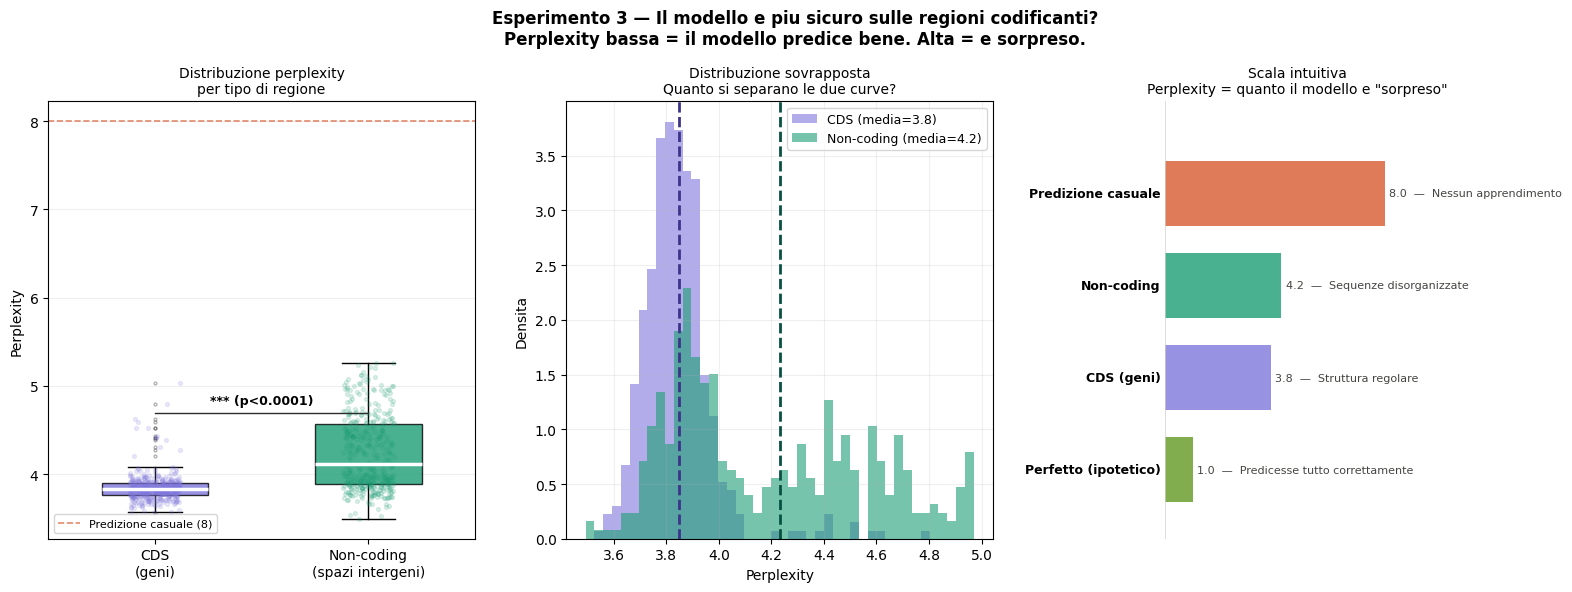

Salvato in figures/exp3_perplexity.png


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Esperimento 3 — Il modello e piu sicuro sulle regioni codificanti?\n'
    'Perplexity bassa = il modello predice bene. Alta = e sorpreso.',
    fontsize=12, fontweight='bold'
)

cds_color = '#7F77DD'
nc_color  = '#1D9E75'
random_ppl = config.vocab_size

# --- Pannello 1: boxplot con singoli punti ---
ax1 = axes[0]
data   = [cds_ppl, nc_ppl]
colors = [cds_color, nc_color]
labels_box = ['CDS\n(geni)', 'Non-coding\n(spazi intergeni)']

bp = ax1.boxplot(data, labels=labels_box, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3),
                 widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Aggiungi singoli punti (jittered)
for i, (vals, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.uniform(-0.12, 0.12, len(vals))
    ax1.scatter(np.full(len(vals), i) + jitter, vals,
                alpha=0.15, s=8, color=color, zorder=2)

# Linea baseline casuale
ax1.axhline(random_ppl, color='#D85A30', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f'Predizione casuale ({random_ppl})')
ax1.legend(fontsize=8)
ax1.set_ylabel('Perplexity')
ax1.set_title('Distribuzione perplexity\nper tipo di regione', fontsize=10)
ax1.grid(True, alpha=0.2, axis='y')

# Annotazione significativita statistica
y_max = np.percentile(cds_ppl + nc_ppl, 92)
ax1.plot([1, 2], [y_max, y_max], color='#2C2C2A', linewidth=1)
sig_label = f'p={pvalue:.4f}' if pvalue > 0.0001 else 'p<0.0001'
star = '***' if pvalue < 0.001 else ('**' if pvalue < 0.01 else ('*' if pvalue < 0.05 else 'n.s.'))
ax1.text(1.5, y_max * 1.02, f'{star} ({sig_label})',
         ha='center', fontsize=9, fontweight='bold')

# --- Pannello 2: istogramma sovrapposto ---
ax2 = axes[1]
clip_max = np.percentile(cds_ppl + nc_ppl, 97)
bins = np.linspace(min(min(cds_ppl), min(nc_ppl)), clip_max, 45)

ax2.hist(cds_ppl, bins=bins, alpha=0.6, color=cds_color, density=True,
         label=f'CDS (media={np.mean(cds_ppl):.1f})')
ax2.hist(nc_ppl,  bins=bins, alpha=0.6, color=nc_color,  density=True,
         label=f'Non-coding (media={np.mean(nc_ppl):.1f})')
ax2.axvline(np.mean(cds_ppl), color='#3C3489', linestyle='--', linewidth=2)
ax2.axvline(np.mean(nc_ppl),  color='#085041', linestyle='--', linewidth=2)
ax2.set_xlabel('Perplexity')
ax2.set_ylabel('Densita')
ax2.set_title('Distribuzione sovrapposta\nQuanto si separano le due curve?', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

# --- Pannello 3: confronto visivo intuitivo ---
ax3 = axes[2]
ax3.axis('off')


categories = [
    ('Predizione casuale', random_ppl, '#D85A30', 'Nessun apprendimento'),
    ('Non-coding',         np.mean(nc_ppl), nc_color, 'Sequenze disorganizzate'),
    ('CDS (geni)',         np.mean(cds_ppl), cds_color, 'Struttura regolare'),
    ('Perfetto (ipotetico)', 1.0, '#639922', 'Predicesse tutto correttamente'),
]

max_ppl = random_ppl * 1.05
bar_h   = 0.14
ys      = [0.75, 0.55, 0.35, 0.15]

for (name, ppl, color, desc), y in zip(categories, ys):
    width = ppl / max_ppl
    ax3.barh(y, width, height=bar_h, color=color, alpha=0.8,
             left=0, align='center')
    ax3.text(-0.02, y, name, ha='right', va='center', fontsize=9, fontweight='bold')
    ax3.text(width + 0.02, y, f'{ppl:.1f}  —  {desc}',
             ha='left', va='center', fontsize=8, color='#444441')

ax3.set_xlim(-0.35, 1.5)
ax3.set_ylim(0, 0.95)
ax3.set_title('Scala intuitiva\nPerplexity = quanto il modello e "sorpreso"', fontsize=10)
ax3.axvline(0, color='#D3D1C7', linewidth=0.5)

plt.tight_layout()
plt.savefig('figures/exp3_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato in figures/exp3_perplexity.png')

In [118]:
delta = np.mean(nc_ppl) - np.mean(cds_ppl)
print('=' * 55)
print('RISULTATO ESPERIMENTO 3')
print('=' * 55)
print(f'CDS:        {np.mean(cds_ppl):.2f}')
print(f'Non-coding: {np.mean(nc_ppl):.2f}')
print(f'Casuale:    {random_ppl:.2f}')
print()
print(f'Il modello e il {(random_ppl - np.mean(cds_ppl))/random_ppl*100:.1f}% piu sicuro rispetto al caso.')
if delta > 0 and pvalue < 0.05:
    print(f'Le CDS sono significativamente piu prevedibili (p={pvalue:.4f}).')
    print('Confermato: il modello ha imparato struttura biologica.')
elif delta > 0:
    print(f'Trend positivo (delta={delta:.2f}) ma non significativo.')
else:
    print('Risultato inatteso: non-coding piu prevedibile di CDS.')
    print('Possibile causa: training breve o dataset sbilanciato.')

RISULTATO ESPERIMENTO 3
CDS:        3.85
Non-coding: 4.23
Casuale:    8.00

Il modello e il 51.9% piu sicuro rispetto al caso.
Le CDS sono significativamente piu prevedibili (p=0.0000).
Confermato: il modello ha imparato struttura biologica.


---
## Esperimento 4 — Il modello ha scoperto la periodicità del codone?

Sappiamo che il DNA è scritto in "parole" di 3 lettere, i codoni. Ogni aminoacido è codificato
da una tripletta, e il riboosoma legge il messaggero esattamente 3 nucleotidi per volta.
Questo crea una **periodicità period-3** nelle sequenze CDS: le 3 posizioni all'interno
di un codone hanno proprietà statistiche diverse.

**In particolare:**
- **Posizione 1** (1° nucleotide del codone): molto vincolata — determina insieme
  alla 2° posizione quale classe di aminoacido viene codificato
- **Posizione 2** (2° nucleotide): altamente vincolata — la più determinante
  per il tipo di aminoacido
- **Posizione 3** (wobble position): più libera e meno vincolata dalla necessità
  di specificare l'aminoacido, ma soggetta al codon usage bias di *E. coli*

**Ipotesi:** se il modello ha imparato la struttura a codoni, la perplexity dovrebbe
variare sistematicamente con la posizione nel codone. In *E. coli* il GC content
è ~51% nella 3a posizione del codone (GC3 bias), quindi ci aspettiamo:

```
perplexity(pos 2) < perplexity(pos 0) < perplexity(pos 1)
  wobble (più    prevedibile per GC3)    1° nucl.
         prevedibile                     (più vincolato per AA)
```

> 💡 **Questo è il test più diretto:** stai chiedendo al modello
> "sai leggere il DNA a triplette?" senza dirglielo.

In [119]:
@torch.no_grad()
def perplexity_by_codon_position(model, tokenizer, sequences, max_seqs=300):
    """
    Calcola la cross-entropy separatamente per la 1a, 2a e 3a posizione del codone
    su sequenze CDS in-frame.

    Returns:
        dict {0: [losses], 1: [losses], 2: [losses]}
        dove 0 = 1a posizione, 1 = 2a, 2 = 3a (wobble)
    """
    model.eval()
    losses_by_pos = {0: [], 1: [], 2: []}

    for seq in sequences[:max_seqs]:

        if len(seq) < 60 or len(seq) % 3 != 0:
            continue
        tokens = tokenizer.encode(seq)
        tokens = tokens[:config.context_len]
        if len(tokens) < 20:
            continue

        x = torch.tensor([tokens[:-1]]).to(device)
        y = torch.tensor([tokens[1:]]).to(device)
        logits, _, _ = model(x)


        for t_idx in range(len(tokens) - 1):
            target_tok = tokens[t_idx + 1]
            if target_tok == 0:
                continue
            codon_pos = t_idx % 3
            log_prob = F.log_softmax(logits[0, t_idx], dim=-1)
            loss_val = -log_prob[target_tok].item()
            losses_by_pos[codon_pos].append(loss_val)

    return losses_by_pos


print("Calcolo perplexity per posizione nel codone (su CDS in-frame)...")
losses_pos = perplexity_by_codon_position(
    model, tokenizer, regions['cds'], max_seqs=300
)

ppl_pos = {pos: math.exp(min(np.mean(losses), 10))
           for pos, losses in losses_pos.items()}

print(f"\nPerplexity per posizione nel codone:")
pos_names = {0: "1ª pos. (1° nucl.)", 1: "2ª pos. (2° nucl.)", 2: "3ª pos. wobble"}
for pos in [0, 1, 2]:
    print(f"  {pos_names[pos]}: {ppl_pos[pos]:.3f}  (n={len(losses_pos[pos]):,})")


Calcolo perplexity per posizione nel codone (su CDS in-frame)...

Perplexity per posizione nel codone:
  1ª pos. (1° nucl.): 3.973  (n=46,872)
  2ª pos. (2° nucl.): 3.903  (n=46,572)
  3ª pos. wobble: 3.595  (n=46,572)


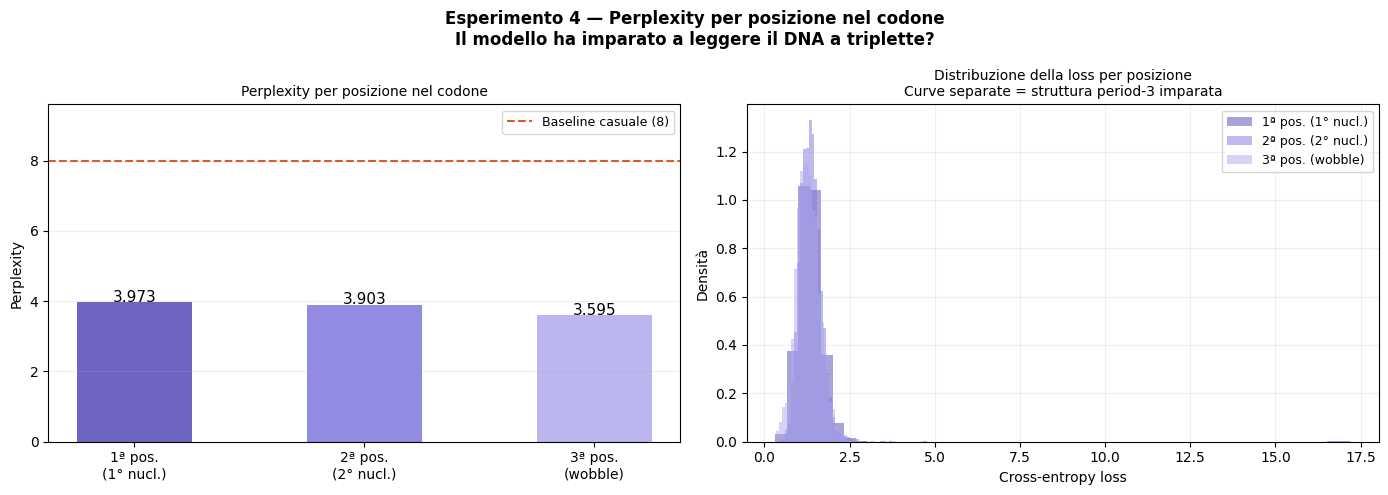

Salvato in figures/exp4_codon_periodicity.png

RISULTATO ESPERIMENTO 4
  1ª posizione: 3.973
  2ª posizione: 3.903
  3ª posizione (wobble): 3.595

POSITIVO — variazione sistematica tra le posizioni del codone.
Il modello ha imparato che le 3 posizioni del codone non sono equivalenti.


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Esperimento 4 — Perplexity per posizione nel codone\n"
    "Il modello ha imparato a leggere il DNA a triplette?",
    fontsize=12, fontweight="bold"
)

pos_labels = ["1ª pos.\n(1° nucl.)", "2ª pos.\n(2° nucl.)", "3ª pos.\n(wobble)"]
pos_colors = ["#534AB7", "#7F77DD", "#AFA9EC"]
ppl_vals   = [ppl_pos[0], ppl_pos[1], ppl_pos[2]]


ax1 = axes[0]
bars = ax1.bar(pos_labels, ppl_vals, color=pos_colors,
               edgecolor="none", alpha=0.85, width=0.5)
for bar, val in zip(bars, ppl_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=11, fontweight="500")

ax1.axhline(config.vocab_size, color="#D85A30", linestyle="--",
            linewidth=1.5, label=f"Baseline casuale ({config.vocab_size})")
ax1.set_ylabel("Perplexity")
ax1.set_title("Perplexity per posizione nel codone", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2, axis="y")
ax1.set_ylim(0, config.vocab_size * 1.2)


ax2 = axes[1]
for pos, color, label in zip([0, 1, 2], pos_colors, pos_labels):
    sample = np.array(losses_pos[pos][:5000])
    ax2.hist(sample, bins=50, alpha=0.5, color=color,
             density=True, label=label.replace("\n", " "))

ax2.set_xlabel("Cross-entropy loss")
ax2.set_ylabel("Densità")
ax2.set_title("Distribuzione della loss per posizione\nCurve separate = struttura period-3 imparata", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("figures/exp4_codon_periodicity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato in figures/exp4_codon_periodicity.png")

# Risultato
print()
print("=" * 55)
print("RISULTATO ESPERIMENTO 4")
print("=" * 55)
expected_order = ppl_pos[2] <= ppl_pos[0] <= ppl_pos[1]
alt_order      = ppl_pos[1] <= ppl_pos[2] <= ppl_pos[0]
print(f"  1ª posizione: {ppl_pos[0]:.3f}")
print(f"  2ª posizione: {ppl_pos[1]:.3f}")
print(f"  3ª posizione (wobble): {ppl_pos[2]:.3f}")
print()
diff_max_min = max(ppl_vals) - min(ppl_vals)
if diff_max_min > 0.1:
    print("POSITIVO — variazione sistematica tra le posizioni del codone.")
    print("Il modello ha imparato che le 3 posizioni del codone non sono equivalenti.")
    if expected_order:
        print("Ordine atteso (wobble più bassa): confermato.")
        print("Il GC3 bias di E. coli è riflesso nel modello.")
else:
    print("DEBOLE/NEGATIVO — poca variazione tra le posizioni.")
    print("Il modello non distingue le 3 posizioni del codone.")
    print("Possibili cause: training breve, sequenze non in-frame,")
    print("o il segnale period-3 non è abbastanza forte nel dataset.")


---
## Esperimento 5 — Il modello riflette il codon usage bias di *E. coli*?

Il **codon usage bias** è il fenomeno per cui organismi diversi preferiscono
certi codoni sinonimi rispetto ad altri. *E. coli* K-12 ha uno dei bias più
estremi tra i batteri:

| Aminoacido | Codone preferito | Frequenza in *E. coli* |
|---|---|---|
| Leucina | CTG | ~50% di tutti i codoni Leu |
| Lisina | AAA | ~76% di tutti i codoni Lys |
| Glutammato | GAA | ~68% di tutti i codoni Glu |

Questo bias esiste perché i tRNA più abbondanti in *E. coli* corrispondono
ai codoni più frequenti — usare il codone giusto accelera la traduzione.

**Ipotesi:** se il modello ha imparato la "lingua" specifica di *E. coli*
(non solo DNA generico), le probabilità che assegna ai codoni sinonimi
dovrebbero correlare con la loro frequenza reale nel genoma.

**Come lo misuriamo:**
Per ogni CDS in-frame, calcoliamo la probabilità che il modello assegna
a ciascun codone: P(N3 | N1, N2, contesto_precedente). Confrontiamo
il ranking del modello con il ranking del codon usage reale di *E. coli*
usando la correlazione di **Spearman** — robusta e non lineare.

> 💡 Correlazione alta = il modello ha imparato la lingua specifica di *E. coli*,
> non solo i pattern generici del DNA.

In [120]:
@torch.no_grad()
def compute_codon_probs_from_sequences(model, tokenizer, regions, max_seqs=400):
    """
    Per ogni codone in ogni CDS in-frame, calcola P(N3 | N1, N2, contesto_precedente).
    Restituisce dict {codon_str: [lista di log-prob]}
    """
    model.eval()
    codon_logprobs = defaultdict(list)

    for seq in regions['cds'][:max_seqs]:
        if len(seq) < 30 or len(seq) % 3 != 0:
            continue
        tokens = tokenizer.encode(seq)
        tokens = tokens[:config.context_len]
        if len(tokens) < 10:
            continue

        x = torch.tensor([tokens[:-1]]).to(device)
        logits, _, _ = model(x)
        log_probs = F.log_softmax(logits[0], dim=-1).cpu()  # (T-1, vocab)

        # Per ogni codone in-frame: prendo P(N3 | contesto fino a N2)
        # Il 3° nucl. del codone i è a tokens[1+3i+2] = tokens[3+3i]
        # Nel target (shifted di 1), corrisponde alla posizione 2+3i nel log_probs
        n_codons = len(seq) // 3
        for i in range(n_codons):
            pos_n3 = 2 + 3 * i  # posizione nel log_probs (0-indexed, shifted)
            if pos_n3 >= log_probs.shape[0]:
                break
            codon_str = seq[3*i: 3*i+3]
            if len(codon_str) != 3 or not all(c in 'ATCG' for c in codon_str):
                continue
            n3_tok = tokens[3 + 3*i] if (3 + 3*i) < len(tokens) else None
            if n3_tok is None or n3_tok == 0:
                continue
            lp = log_probs[pos_n3, n3_tok].item()
            codon_logprobs[codon_str].append(lp)

    return {c: np.mean(lps) for c, lps in codon_logprobs.items() if len(lps) >= 5}


print("Calcolo probabilità assegnate dal modello a ciascun codone...")
model_codon_probs = compute_codon_probs_from_sequences(
    model, tokenizer, regions, max_seqs=400
)
print(f"Codoni con stima affidabile: {len(model_codon_probs)}/64")

# Conta la frequenza reale dei codoni nel dataset CDS
real_codon_counts = defaultdict(int)
for seq in regions['cds']:
    if len(seq) % 3 == 0:
        for i in range(0, len(seq)-2, 3):
            codon = seq[i:i+3]
            if all(c in 'ATCG' for c in codon):
                real_codon_counts[codon] += 1

total_codons = sum(real_codon_counts.values())
real_codon_freq = {c: v/total_codons for c, v in real_codon_counts.items()}

print(f"Codoni totali contati nel CDS: {total_codons:,}")

# Calcola correlazione di Spearman tra probabilità del modello e frequenza reale
from scipy.stats import spearmanr

common_codons = sorted(set(model_codon_probs.keys()) & set(real_codon_freq.keys()))
model_scores  = [model_codon_probs[c] for c in common_codons]
real_scores   = [real_codon_freq[c]   for c in common_codons]
rho, pval     = spearmanr(model_scores, real_scores)
print(f"\nCorrelazione di Spearman (modello vs frequenza reale): rho={rho:.3f}, p={pval:.4f}")


Calcolo probabilità assegnate dal modello a ciascun codone...
Codoni con stima affidabile: 63/64
Codoni totali contati nel CDS: 1,341,465

Correlazione di Spearman (modello vs frequenza reale): rho=0.600, p=0.0000


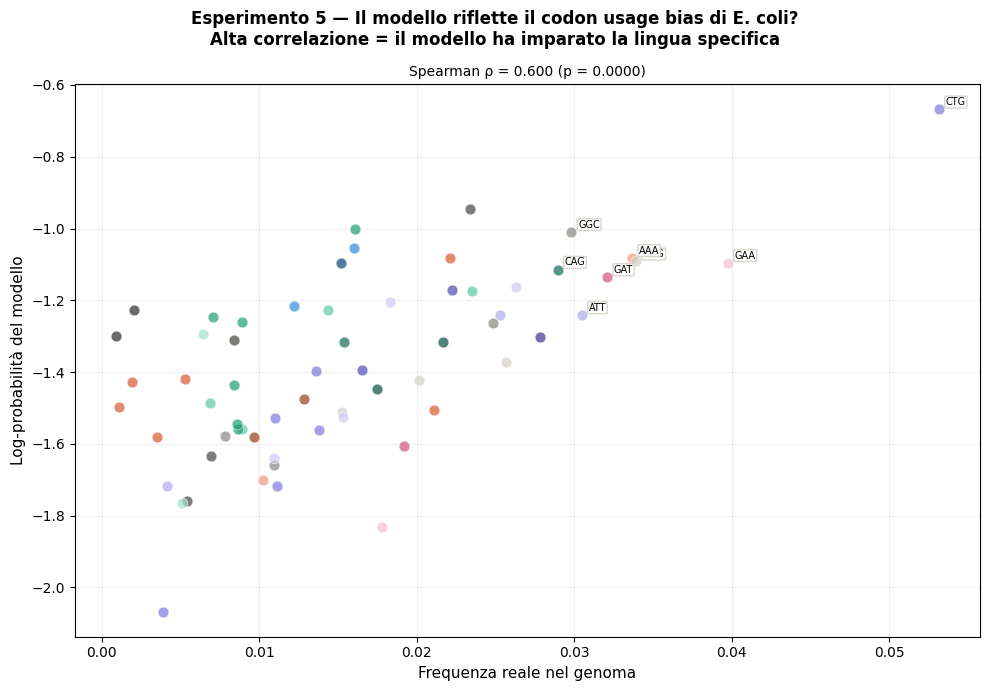

In [126]:
from scipy.stats import spearmanr

fig, ax1 = plt.subplots(figsize=(10, 7))

fig.suptitle(
    "Esperimento 5 — Il modello riflette il codon usage bias di E. coli?\n"
    "Alta correlazione = il modello ha imparato la lingua specifica",
    fontsize=12, fontweight="bold"
)


for codon in common_codons:
    aa = GENETIC_CODE.get(codon, 'Stop')
    color = AA_COLORS.get(aa, "#888780")
    ax1.scatter(
        real_codon_freq[codon],
        model_codon_probs[codon],
        c=color, s=60, alpha=0.7, zorder=3,
        edgecolors="white", linewidths=0.5
    )


top_codons = sorted(common_codons, key=lambda c: real_codon_freq[c], reverse=True)[:8]
for codon in top_codons:
    ax1.annotate(
        codon,
        xy=(real_codon_freq[codon], model_codon_probs[codon]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7,
        bbox=dict(boxstyle="round,pad=0.1", facecolor="white",
                  edgecolor="#D3D1C7", alpha=0.9)
    )

ax1.set_xlabel("Frequenza reale nel genoma", fontsize=11)
ax1.set_ylabel("Log-probabilità del modello", fontsize=11)
ax1.set_title(
    f"Spearman ρ = {rho:.3f} (p = {pval:.4f})",
    fontsize=10
)
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/exp5_codon_usage_bias.png', dpi=150)
plt.show()

---
## Esperimento 6 — Il modello scrive geni plausibili?

Invece di analizzare sequenze esistenti, ora **usiamo il modello come generatore**:
gli forniamo il codone di start (`ATG`) e lo lasciamo completare liberamente la sequenza.

Un modello che ha imparato la struttura biologica del genoma di *E. coli* dovrebbe
generare sequenze che:
1. **Mantengono il frame del codone** : i codoni di stop compaiono a multipli di 3
2. **Hanno pochi stop codon prematuri** : in un gene reale, i stop compaiono solo alla fine
3. **Riflettono il codon usage di *E. coli*** : CTG dovrebbe essere il Leu più comune
4. **Hanno la composizione nucleotidica corretta** : ~51% GC, non uniforme

> 🧬 **Nota:** non ci aspettiamo che il modello generi geni funzionali
> sarebbe impossibile con soli ~3M parametri. Ma possiamo verificare se le sequenze
> generate **assomigliano statisticamente** alle CDS reali.

In [127]:
@torch.no_grad()
def generate_from_start(model, tokenizer, n_generate=200,
                        temperature=0.8, n_sequences=20):
    """
    Genera sequenze partendo dal prompt [BOS, A, T, G].
    Usa model.generate() — già implementato e testato nella cella architettura.
    Restituisce lista di stringhe DNA generate.
    """
    model.eval()
    bos_id = tokenizer.vocab['<BOS>']
    eos_id = tokenizer.vocab['<EOS>']
    id2nt  = {v: k for k, v in tokenizer.vocab.items()
              if k in ('A', 'T', 'C', 'G')}

    prompt = [bos_id,
              tokenizer.vocab['A'],
              tokenizer.vocab['T'],
              tokenizer.vocab['G']]   # BOS + ATG

    generated_seqs = []
    for _ in range(n_sequences):
        prompt_tensor = torch.tensor([prompt]).to(device)
        # usa model.generate() — già implementato e testato
        out = model.generate(prompt_tensor, max_new_tokens=n_generate,
                             temperature=temperature)  # (1, T)
        tokens = out[0].tolist()
        # tronca all'EOS se presente
        if eos_id in tokens:
            tokens = tokens[:tokens.index(eos_id)]
        seq = ''.join(id2nt.get(t, '') for t in tokens[1:])  # escludi BOS
        generated_seqs.append(seq)

    return generated_seqs


print("Generazione sequenze partendo da ATG (start codon)...")
generated = generate_from_start(
    model, tokenizer,
    n_generate=300, temperature=0.8, n_sequences=50
)
print(f"Generate {len(generated)} sequenze")
print(f"Lunghezza media: {np.mean([len(s) for s in generated]):.1f} nt")
print(f"\nEsempio (prima sequenza, prime 60 nt):")
print(generated[0][:60] if generated else "(nessuna)")


STOP_CODONS = {"TAA", "TAG", "TGA"}

def find_in_frame_stop(seq):
    """Trova il primo stop codon in frame (partendo da pos 0, ogni 3 nt)."""
    for i in range(0, len(seq)-2, 3):
        codon = seq[i:i+3]
        if codon in STOP_CODONS:
            return i
    return None

stop_positions = [find_in_frame_stop(s) for s in generated]
n_with_stop    = sum(1 for p in stop_positions if p is not None)
early_stops    = sum(1 for p in stop_positions if p is not None and p < 60)

print(f"\nAnalisi stop codon in-frame:")
print(f"  Sequenze con stop in-frame: {n_with_stop}/{len(generated)}")
print(f"  Stop prematuri (< 60 nt): {early_stops}/{len(generated)}")


def gc_content(seq):
    if not seq:
        return 0
    return sum(1 for c in seq if c in "GC") / len(seq)

gen_gc   = [gc_content(s) for s in generated]
real_gc  = [gc_content(s) for s in regions["cds"][:200]]
print(f"\nGC content:")
print(f"  Sequenze generate: {np.mean(gen_gc)*100:.1f}% ± {np.std(gen_gc)*100:.1f}%")
print(f"  CDS reali:         {np.mean(real_gc)*100:.1f}% ± {np.std(real_gc)*100:.1f}%")
print(f"  E. coli genomico atteso: ~51%")


Generazione sequenze partendo da ATG (start codon)...
Generate 50 sequenze
Lunghezza media: 303.0 nt

Esempio (prima sequenza, prime 60 nt):
ATGGTTATTGGCGTTAACAACGTTATGGGTTTGCCGATCGAAACCTATTAGCCGGGATTA

Analisi stop codon in-frame:
  Sequenze con stop in-frame: 49/50
  Stop prematuri (< 60 nt): 21/50

GC content:
  Sequenze generate: 51.7% ± 7.7%
  CDS reali:         52.2% ± 3.6%
  E. coli genomico atteso: ~51%


Correlazione codon usage generato vs reale: rho=0.615, p=0.0000


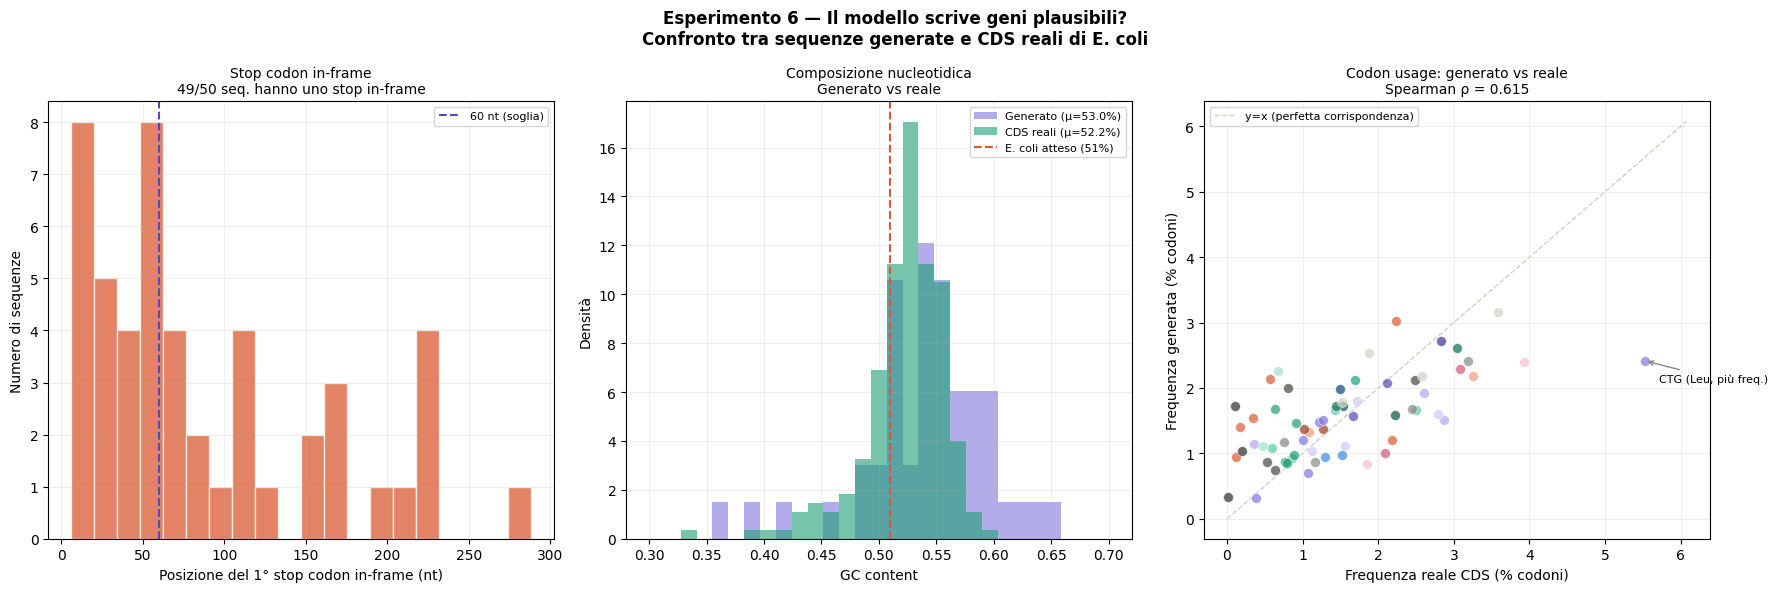

Salvato in figures/exp6_generation.png

RISULTATO ESPERIMENTO 6
GC content generato: 53.0% (atteso ~51%)
Stop prematuri (<60 nt): 24/50
Correlazione codon usage: rho=0.615

POSITIVO — le sequenze generate sono biologicamente plausibili.
  ✓ GC content vicino al valore atteso di E. coli
  ✓ Il codon usage generato correla con quello reale di E. coli


In [84]:
from scipy.stats import  spearmanr

def count_codons_from_seqs(seqs):
    counts = defaultdict(int)
    for seq in seqs:
        for i in range(0, len(seq)-2, 3):
            codon = seq[i:i+3]
            if len(codon) == 3 and all(c in "ATCG" for c in codon):
                counts[codon] += 1
    return counts

gen_counts  = count_codons_from_seqs(generated)
real_counts = count_codons_from_seqs(regions["cds"][:500])

gen_total  = sum(gen_counts.values())
real_total = sum(real_counts.values())
gen_freq   = {c: n/gen_total  for c, n in gen_counts.items()}
real_freq  = {c: n/real_total for c, n in real_counts.items()}

all_codons = sorted(GENETIC_CODE.keys())
gen_v  = [gen_freq.get(c, 0)  for c in all_codons]
real_v = [real_freq.get(c, 0) for c in all_codons]
rho_gen, pval_gen = spearmanr(gen_v, real_v)

print(f"Correlazione codon usage generato vs reale: rho={rho_gen:.3f}, p={pval_gen:.4f}")


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Esperimento 6 — Il modello scrive geni plausibili?\n"
    "Confronto tra sequenze generate e CDS reali di E. coli",
    fontsize=12, fontweight="bold"
)


ax1 = axes[0]
stop_pos_valid = [p for p in stop_positions if p is not None]
if stop_pos_valid:
    ax1.hist(stop_pos_valid, bins=20, color="#D85A30", alpha=0.75, edgecolor="white")
ax1.set_xlabel("Posizione del 1° stop codon in-frame (nt)")
ax1.set_ylabel("Numero di sequenze")
ax1.set_title(
    f"Stop codon in-frame\n"
    f"{n_with_stop}/{len(generated)} seq. hanno uno stop in-frame",
    fontsize=10
)
ax1.axvline(60, color="#534AB7", linestyle="--", label="60 nt (soglia)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)


ax2 = axes[1]
bins = np.linspace(0.3, 0.7, 30)
ax2.hist(gen_gc,  bins=bins, alpha=0.6, color="#7F77DD",
         density=True, label=f"Generato (μ={np.mean(gen_gc)*100:.1f}%)")
ax2.hist(real_gc, bins=bins, alpha=0.6, color="#1D9E75",
         density=True, label=f"CDS reali (μ={np.mean(real_gc)*100:.1f}%)")
ax2.axvline(0.51, color="#D85A30", linestyle="--", linewidth=1.5,
            label="E. coli atteso (51%)")
ax2.set_xlabel("GC content")
ax2.set_ylabel("Densità")
ax2.set_title("Composizione nucleotidica\nGenerato vs reale", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)


ax3 = axes[2]
for codon in all_codons:
    aa = GENETIC_CODE.get(codon, "Stop")
    color = AA_COLORS.get(aa, "#888780")
    ax3.scatter(
        real_freq.get(codon, 0) * 100,
        gen_freq.get(codon, 0) * 100,
        c=color, s=50, alpha=0.7, zorder=3,
        edgecolors="white", linewidths=0.5
    )

# Annota CTG
ctg_real = real_freq.get("CTG", 0) * 100
ctg_gen  = gen_freq.get("CTG", 0)  * 100
ax3.annotate("CTG (Leu, più freq.)",
             xy=(ctg_real, ctg_gen),
             xytext=(10, -15), textcoords="offset points",
             fontsize=8, arrowprops=dict(arrowstyle="->", color="#888780"))

lims = [0, max(max(real_v), max(gen_v)) * 110]
ax3.plot([0, lims[1]], [0, lims[1]], color="#D3D1C7",
         linestyle="--", linewidth=1, label="y=x (perfetta corrispondenza)")
ax3.set_xlabel("Frequenza reale CDS (% codoni)")
ax3.set_ylabel("Frequenza generata (% codoni)")
ax3.set_title(
    f"Codon usage: generato vs reale\n"
    f"Spearman ρ = {rho_gen:.3f}",
    fontsize=10
)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("figures/exp6_generation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato in figures/exp6_generation.png")

print()
print("=" * 55)
print("RISULTATO ESPERIMENTO 6")
print("=" * 55)
print(f"GC content generato: {np.mean(gen_gc)*100:.1f}% (atteso ~51%)")
print(f"Stop prematuri (<60 nt): {early_stops}/{len(generated)}")
print(f"Correlazione codon usage: rho={rho_gen:.3f}")
print()
gc_ok    = abs(np.mean(gen_gc) - 0.51) < 0.05
stop_ok  = early_stops < len(generated) * 0.3
corr_ok  = rho_gen > 0.4
n_ok = sum([gc_ok, stop_ok, corr_ok])
if n_ok >= 2:
    print("POSITIVO — le sequenze generate sono biologicamente plausibili.")
    if gc_ok:
        print("  ✓ GC content vicino al valore atteso di E. coli")
    if stop_ok:
        print("  ✓ Pochi stop codon prematuri — il modello evita di terminare presto")
    if corr_ok:
        print("  ✓ Il codon usage generato correla con quello reale di E. coli")
else:
    print("PARZIALE/NEGATIVO — le sequenze generate non sono molto plausibili.")
    print("Il modello ha imparato qualcosa ma non abbastanza per generare")
    print("sequenze con caratteristiche biologiche consistenti.")
